#MAPEO DE SERIES DE TIEMPO DE ANOMALÍAS DE ENOS Y CAUDAL

##DEFINICIONES

In [1]:
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt


# ============================================================
# Mapeo global de permutaciones (predefinido para w=4)
# ============================================================

# Generar todas las permutaciones posibles de (1,2,3,4)
w_fijo = 4
permutaciones = list(itertools.permutations(range(1, w_fijo+1)))
permutaciones.sort()  # Orden lexicográfico para consistencia

# Crear mapeos globales
MAQUINA_ESTADOS = {perm: idx for idx, perm in enumerate(permutaciones)}  # perm -> índice 0-23
INDICE_A_PERM = {idx: perm for idx, perm in enumerate(permutaciones)}  # índice -> perm
NUM_NODOS_GLOBAL = len(permutaciones)  # 24

# ============================================================
# 1. Crear nodos (ordinal patterns) - MODIFICADA
# ============================================================

def crear_ind(x, tamaño_w):
    """
    Devuelve la lista de patrones ordinales mapeados a índices globales.
    Usa el mapeo MAQUINA_ESTADOS para garantizar consistencia.
    """
    x = np.asarray(x)
    N = len(x)
    w = int(tamaño_w)
    if N < w:
        return []

    ind_x1 = []
    for i in range(0, N - w + 1):
        sub = x[i:i+w]

        # Orden de índices de mayor a menor (Small 2013 define orden por "pi_j-th largest")
        order_desc = np.argsort(sub, kind='stable')[::-1]  # índices del mayor al menor

        # Construir ranking: ranks[pos] = 1..w (1 = mayor)
        ranks = np.empty(w, dtype=int)
        ranks[order_desc] = np.arange(1, w+1)

        pat = tuple(ranks.tolist())
        # Mapear a índice global usando MAQUINA_ESTADOS
        idx = MAQUINA_ESTADOS[pat]
        ind_x1.append(idx)

    return ind_x1

# ============================================================
# 2. Crear grafo (ahora PESADO) - MODIFICADA
# ============================================================

def crear_grafo(ind_x1, tamaño_w):
    """
    Construye un grafo NO dirigido y PESADO con 24 nodos fijos.
    La matriz de adyacencia siempre es de 24×24.
    """
    # Crear grafo con todos los nodos posibles (0-23)
    G = nx.Graph()
    for i in range(NUM_NODOS_GLOBAL):
        G.add_node(i)

    # Inicializar diccionario de etiquetas
    nodo_a_sublista = INDICE_A_PERM.copy()  # copia del mapeo global

    # Añadir aristas incrementando peso (transiciones cada w pasos)
    w = int(tamaño_w)
    for i in range(len(ind_x1) - w):
        a = ind_x1[i]  # ya es índice global
        b = ind_x1[i + w]  # ya es índice global
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

    # unique_nodes es el mapeo inverso para compatibilidad
    unique_nodes = {perm: idx for idx, perm in INDICE_A_PERM.items()}

    return G, unique_nodes, nodo_a_sublista

# ============================================================
# 3. Calcular entropía usando matriz de conectividad PESADA - MODIFICADA
# ============================================================

def calcular_entropia(unique_nodes, ind_x1, w):
    """
    Calcula entropía con matriz de adyacencia de 24×24.
    """
    # Inicializar matriz 24×24 (no usa unique_nodes para el tamaño)
    matriz_conectividad = np.zeros((NUM_NODOS_GLOBAL, NUM_NODOS_GLOBAL), dtype=int)

    w_int = int(w)
    # Rellenar matriz con conteos de transiciones
    for i in range(len(ind_x1) - w_int):
        a = ind_x1[i]  # índice global
        b = ind_x1[i + w_int]  # índice global
        matriz_conectividad[a, b] += 1
        matriz_conectividad[b, a] += 1  # red no dirigida

    # sumas por fila = fuerza (grado ponderado)
    sum_m = matriz_conectividad.sum(axis=1)

    mu = []
    for i in range(NUM_NODOS_GLOBAL):
        if sum_m[i] == 0:
            mu.append(0.0)
            continue
        ent = 0.0
        for j in range(NUM_NODOS_GLOBAL):
            if matriz_conectividad[i, j] > 0:
                p = matriz_conectividad[i, j] / sum_m[i]
                ent -= p * np.log2(p)
        mu.append(ent)

    mut = float(np.mean(mu)) if NUM_NODOS_GLOBAL > 0 else 0.0

    return mu, mut, matriz_conectividad




In [2]:
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Extraer patrones ordinales (para cualquier w)
# ------------------------------------------------------------
def obtener_patrones(x, w):
    
    """
    Devuelve una lista de tuplas, cada una es el patrón ordinal (permutación)
    de una ventana deslizante de longitud w sobre la serie x.
    El orden es de mayor a menor, con desempate estable (primero aparece = más pequeño).
    """
    x = np.asarray(x)
    N = len(x)
    if N < w:
        return []
    patrones = []
    for i in range(N - w + 1):
        sub = x[i:i+w]
        # Índices ordenados de mayor a menor (argsort descendente estable)
        order_desc = np.argsort(sub, kind='stable')[::-1]
        # Asignar rangos: 1 al más grande, w al más pequeño
        ranks = np.empty(w, dtype=int)
        ranks[order_desc] = np.arange(1, w+1)
        patrones.append(tuple(ranks))
    return patrones

# ------------------------------------------------------------
# 2. Construir grafo a partir de la lista de patrones
# ------------------------------------------------------------
def construir_grafo(patrones, w):
    """
    Construye un grafo no dirigido y pesado.
    - Nodos: patrones ordinales distintos que aparecen en la serie.
    - Aristas: entre patrones que ocurren en tiempos sucesivos no solapados
               (separados por w pasos). El peso acumula el número de transiciones.
    """
    # Mapear cada patrón único a un índice local
    unique_pat = {}
    for p in patrones:
        if p not in unique_pat:
            unique_pat[p] = len(unique_pat)
    num_nodes = len(unique_pat)

    # Crear grafo con todos los nodos (inicialmente aislados)
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))

    # Añadir aristas con peso (transiciones cada w pasos, sin solapamiento)
    for i in range(len(patrones) - w):
        a = unique_pat[patrones[i]]
        b = unique_pat[patrones[i + w]]
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

    # También devolvemos el mapeo inverso (índice -> patrón) por si se necesita
    idx_to_pat = {v: k for k, v in unique_pat.items()}
    return G, idx_to_pat

# ------------------------------------------------------------
# 3. Calcular entropía de la red (promedio de entropías nodales)
# ------------------------------------------------------------
def calcular_entropia_red(G):
    """
    Calcula la entropía nodal promedio para un grafo pesado no dirigido.
    Para cada nodo i: μ(i) = - Σ_j p(i,j) log2 p(i,j), con p(i,j) = peso(i,j) / fuerza(i).
    La entropía total es el promedio sobre todos los nodos.
    Los nodos aislados contribuyen con 0.
    """
    entropias = []
    for node in G.nodes():
        # Obtener pesos de las aristas incidentes
        weights = [G[node][nbr]['weight'] for nbr in G.neighbors(node)]
        strength = sum(weights)
        if strength == 0:
            entropias.append(0.0)
            continue
        # Calcular entropía
        ent = 0.0
        for wgt in weights:
            p = wgt / strength
            ent -= p * np.log2(p)
        entropias.append(ent)
    return np.mean(entropias) if entropias else 0.0

# ------------------------------------------------------------
# 4. Función de optimización de w (adaptada)
# ------------------------------------------------------------
def optimizar_w(x, w_min, w_max):
    """
    Encuentra el valor óptimo de w que maximiza la entropía promedio de la red.

    Parámetros:
        x (list): Serie temporal.
        w_min (int): Valor mínimo de w (inclusive).
        w_max (int): Valor máximo de w (exclusive, como en range).

    Retorna:
        w_optimo (int): w que maximiza la entropía.
    """
    valores_w = range(w_min, w_max)
    entropias = []

    for w in valores_w:
        # 1. Obtener patrones ordinales
        patrones = obtener_patrones(x, w)
        if len(patrones) < w + 1:   # se necesitan al menos dos transiciones
            entropias.append(0.0)
            continue

        # 2. Construir grafo
        G, _ = construir_grafo(patrones, w)

        # 3. Calcular entropía promedio
        ent = calcular_entropia_red(G)
        entropias.append(ent)

    # Encontrar w óptimo
    idx_opt = np.argmax(entropias)
    w_optimo = valores_w[idx_opt]

    # Graficar
    plt.figure(figsize=(8, 5))
    plt.plot(valores_w, entropias, marker='o', linestyle='-', color='black')
    plt.axvline(x=w_optimo, color='r', linestyle='--',
                label=f'$w_{{opt}}$ = {w_optimo}')
    plt.xlabel('Tamaño de ventana w')
    plt.ylabel('Entropía promedio de la red')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})
    plt.show()

    return w_optimo


In [3]:
# Después de crear el grafo:
def contar_nodos_activos(G):
    """
    Cuenta cuántos nodos de los 24 tienen al menos una conexión.
    """
    nodos_activos = 0
    for nodo in G.nodes():
        if G.degree(nodo, weight='weight') > 0:
            nodos_activos += 1
    return nodos_activos

#MAPEO NIÑO 3.4

len() de nodos es 801
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
len() de unique_nodes es 24
El grado medio de la red es: 14.5
La distancia minima promedio de la red es: 1.394927536231884
la distancia maxima es: 2
[[36. 19.  8.  5.  1.  2. 15.  1.  3.  6.  1. 10. 10.  2.  4.  3.  3. 14.
   4.  0.  8. 15. 22. 64.]
 [19.  3.  3.  4.  1.  4.  7.  2.  2.  2.  1.  2.  3.  0.  1.  1.  2.  8.
   1.  0.  1.  2.  7. 20.]
 [ 8.  3.  0.  3.  0.  0.  3.  0.  1.  0.  0.  4.  1.  0.  0.  0.  0.  1.
   1.  0.  3.  0.  3.  8.]
 [ 5.  4.  3.  0.  1.  0.  3.  1.  0.  0.  0.  1.  4.  1.  2.  1.  1.  6.
   0.  0.  1.  4.  3.  7.]
 [

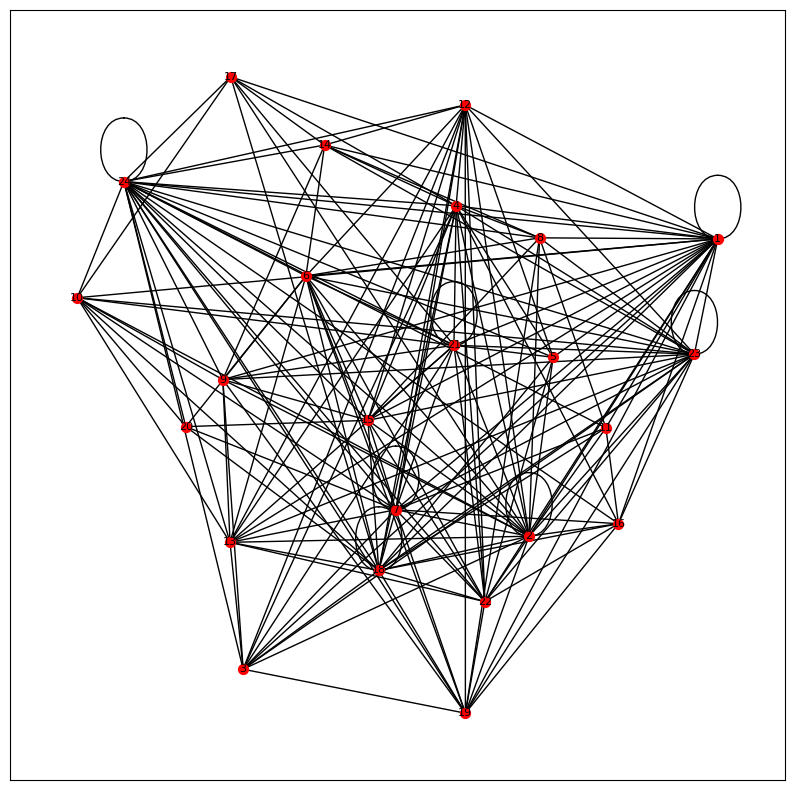

In [4]:

w_opt=4
x =[
-1.99, -1.69, -1.42, -1.54, -1.75, -1.27, -1.01, -0.97, -0.98, -1.03,
-1.23, -1.31, -1.30, -1.04, -0.38, -0.23, -0.01, 0.00, 0.30, 0.17,
0.51, 0.49, 0.55, 0.31, 0.13, -0.01, -0.11, -0.02, -0.14, -0.54,
-0.76, -0.56, -0.36, -0.46, -0.78, -0.39, 0.20, 0.24, 0.29, 0.22,
0.35, 0.39, 0.14, 0.09, 0.29, 0.16, 0.18, 0.41, 0.43, 0.28,
-0.38, -1.17, -0.81, -0.93, -1.18, -1.43, -1.60, -1.48, -1.13, -1.33,
-0.93, -0.95, -1.06, -1.22, -1.28, -1.18, -1.15, -1.35, -1.43, -2.31,
-2.45, -2.03, -1.20, -0.99, -0.83, -0.97, -0.80, -0.92, -1.06, -1.17,
-0.98, -0.97, -1.14, -0.89, -0.51, -0.22, 0.18, 0.41, 0.62, 0.63,
0.87, 0.84, 0.72, 0.70, 0.92, 1.30, 1.78, 1.49, 0.98, 0.46,
0.38, 0.26, 0.03, -0.01, -0.32, -0.27, 0.05, 0.02, 0.53, 0.43,
0.19, 0.06, -0.23, -0.35, -0.86, -0.77, -0.80, -0.48, -0.66, -0.42,
-0.28, -0.46, -0.30, -0.33, -0.25, -0.49, -0.41, -0.15, -0.28, -0.49,
-0.45, -0.38, -0.31, -0.19, -0.35, -0.46, -0.18, -0.06, -0.41, -0.67,
-0.94, -1.01, -0.63, -0.63, -0.59, -0.57, -0.48, -0.69, -0.89, -0.65,
-0.53, -0.53, -0.78, -0.75, -0.95, -0.93, -0.78, -0.53, -0.10, -0.03,
-0.30, -0.11, 0.49, 0.62, 0.68, 0.64, 0.77, 1.02, 0.79, 0.38,
-0.26, -0.87, -1.12, -1.14, -0.96, -1.26, -1.40, -1.35, -1.44, -1.37,
-0.89, -0.56, -0.34, -0.44, 0.06, 0.36, 0.61, 1.12, 1.29, 1.45,
1.42, 1.36, 1.12, 0.80, 0.93, 0.35, -0.38, -0.08, 0.04, -0.37,
-0.44, -0.50, -0.47, -0.57, -0.67, -0.64, -0.78, -1.08, -0.59, -0.26,
-0.33, -0.42, -0.86, -0.74, -0.62, -0.65, -0.85, -1.07, -0.95, -0.72,
-0.75, 0.15, 0.28, 0.16, 0.01, 0.04, 0.50, 0.67, 0.95, 1.11, 0.54,
0.31, 0.35, -0.04, -0.21, 0.16, 0.43, 0.62, 0.40, 0.38, 0.28,
0.20, -0.14, -0.08, -0.30, -0.69, -1.08, -1.26, -1.07, -1.12, -1.13,
-1.33, -1.73, -1.57, -1.36, -1.18, -0.98, -1.13, -1.17, -1.10, -1.00,
-1.24, -1.15, -1.23, -0.92, -0.45, -0.19, 0.07, 0.38, 0.45, 0.85,
1.09, 1.23, 1.54, 1.90, 2.09, 1.80, 1.20, 0.27, -0.58, -0.97,
-1.18, -1.54, -1.63, -1.66, -1.98, -2.37, -2.26, -2.09, -1.66, -1.45,
-1.36, -1.29, -1.20, -0.90, -0.52, -0.64, -0.94, -1.09, -0.97, -0.45,
-0.68, -1.09, -0.96, -1.13, -1.50, -1.39, -1.52, -1.66, -1.83, -1.66,
-1.93, -2.01, -1.26, -0.82, -0.93, -0.74, -0.38, -0.16, 0.12, 0.30,
0.75, 0.71, 0.49, 0.78, 0.37, 0.19, -0.38, -0.21, 0.01, 0.09,
-0.01, 0.40, 0.63, 0.48, 0.70, 0.62, 0.25, -0.20, -0.70, -0.74,
-0.71, -0.55, -0.79, -0.71, -0.46, -0.38, -0.06, -0.13, -0.22, -0.02,
0.02, -0.25, -0.29, -0.47, -0.10, 0.28, 0.11, 0.29, 0.52, 0.54,
0.22, 0.03, -0.07, 0.08, 0.21, -0.06, -0.38, -0.28, -0.26, -0.10,
0.05, -0.36, -0.64, -0.64, -0.53, -0.57, -0.46, -0.64, -0.53, -0.19,
-0.30, -0.41, -0.20, 0.13, -0.17, 0.13, 0.21, 0.45, 0.53, 0.37,
0.73, 1.49, 1.99, 1.92, 2.20, 2.35, 1.94, 1.38, 0.95, 0.90,
0.54, -0.11, -0.27, -0.52, -1.16, -1.29, -1.03, -0.67, -0.19, -0.52,
-0.68, -0.73, -0.90, -0.50, -0.24, -0.34, -0.67, -1.19, -1.34, -1.16,
-0.72, -0.79, -1.18, -1.03, -0.91, -0.74, -0.56, -0.70, -0.49, -0.37,
-0.41, -0.66, -0.71, -0.42, -0.33, -0.53, -0.31, -0.11, 0.32, 0.53,
0.81, 1.01, 1.12, 1.14, 1.13, 0.98, 0.58, 0.62, 0.92, 1.29,
1.57, 1.65, 1.24, 1.07, 0.94, 0.90, 0.28, 0.10, -0.44, -1.25,
-1.74, -1.74, -1.19, -1.00, -1.90, -2.05, -1.96, -1.97, -1.47, -1.21,
-1.08, -0.88, -0.59, -0.57, -0.53, -0.30, -0.40, -0.45, -0.13, 0.01,
0.21, 0.04, 0.08, 0.08, -0.08, 0.09, 0.22, 0.22, 0.21, 0.10,
0.35, 0.49, 0.32, 0.03, 0.19, 0.26, 0.52, 0.76, 0.68, 0.42,
0.86, 1.20, 1.69, 1.84, 1.78, 1.38, 1.20, 1.04, 0.58, 0.22,
0.05, -0.06, -0.30, -0.28, -0.15, 0.14, 0.41, 0.39, 0.59, 0.78,
0.35, 0.23, 0.13, 0.35, 0.06, 0.00, 0.16, 0.10, 0.06, 0.11,
0.26, 0.31, 0.32, 0.24, 0.53, 0.48, 0.75, 1.11, 1.25, 1.02,
0.73, 0.46, 0.28, -0.11, -0.14, -0.21, -0.63, -0.84, -0.88, -1.10,
-0.95, -0.86, -0.86, -0.61, -0.47, -0.38, -0.44, -0.44, -0.22, -0.45,
-0.44, -0.41, -0.64, -0.53, -0.37, -0.25, 0.16, 0.64, 1.09, 1.56,
1.89, 2.13, 2.36, 2.41, 2.29, 2.38, 2.03, 1.34, 0.78, 0.57, -0.39,
-0.99, -1.28, -1.26, -1.46, -1.46, -1.69, -1.69, -1.32, -0.95, -1.11,
-1.15, -1.19, -1.17, -1.22, -1.09, -1.23, -1.58, -1.74, -1.77, -1.55,
-0.98, -0.87, -0.86, -0.79, -0.67, -0.49, -0.52, -0.70, -0.79, -0.92,
-0.73, -0.63, -0.48, -0.49, -0.34, -0.19, -0.04, -0.05, -0.20, -0.14,
-0.37, -0.41, -0.15, -0.04, 0.01, 0.02, 0.31, 0.72, 0.74, 0.87,
1.09, 1.25, 1.47, 1.37, 0.60, 0.64, 0.36, -0.14, -0.61, -0.29,
0.21, 0.26, 0.27, 0.42, 0.33, 0.43, 0.27, 0.23, 0.12, 0.07,
0.06, 0.13, 0.49, 0.76, 0.81, 0.73, 0.66, 0.74, 0.66, 0.36,
0.45, 0.26, 0.30, 0.04, -0.23, -0.05, -0.04, -0.06, -0.59, -0.92,
-0.91, -0.67, -0.71, -0.32, -0.09, 0.00, 0.01, 0.31, 0.60, 0.70,
0.99, 1.14, 0.70, 0.13, -0.18, -0.32, -0.47, -0.35, -0.59, -0.72,
-1.11, -1.39, -1.54, -1.58, -1.68, -1.67, -1.21, -0.99, -0.84, -0.68,
-0.30, -0.13, -0.25, -0.35, -0.46, -0.86, -0.89, -0.79, -0.69, -0.35,
0.06, 0.31, 0.48, 0.56, 0.68, 0.89, 1.46, 1.74, 1.52, 1.25, 0.90,
0.38, -0.22, -0.69, -1.07, -1.39, -1.60, -1.69, -1.64, -1.60, -1.54, -1.11,
-0.93, -0.77, -0.52, -0.38, -0.43, -0.65, -0.80, -1.05, -1.19, -1.06,
-0.87, -0.67, -0.61, -0.50, -0.32, 0.02, 0.25, 0.47, 0.38, 0.26,
0.16, -0.25, -0.53, -0.52, -0.25, -0.25, -0.40, -0.42, -0.39, -0.38,
-0.18, -0.20, -0.14, -0.17, -0.49, -0.62, -0.28, 0.08, 0.32, 0.23,
-0.06, -0.03, 0.29, 0.44, 0.75, 0.71, 0.51, 0.42, 0.47, 0.70,
0.92, 1.18, 1.46, 1.93, 2.21, 2.36, 2.72, 2.66, 2.57, 2.26, 1.62,
0.91, 0.30, -0.03, -0.48, -0.58, -0.58, -0.74, -0.76, -0.50
]

nodos = crear_ind(x , w_opt)
print("len() de nodos es",len(nodos))

G, unique_nodes, nodo_a_sublista= crear_grafo(nodos, w_opt)
A = nx.to_numpy_array(G)
print(unique_nodes)
print("len() de unique_nodes es",len(unique_nodes))
# Dibujar el grafo
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G)  # Layout para la visualización
nx.draw_networkx_nodes(G, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G, pos, edge_color="black")
# Etiquetas con índices 1‑based
labels = {i: i+1 for i in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8)
#nx.draw_networkx_labels(G, pos, {i: f"{i}" for i in G.nodes()}, font_size=8)
#MU,MUT,MC=calcular_entropia(unique_nodes,nodos)
#for i in range(len(MC)):
 #   print(MC[i])
#plt.title("Grafo")
def calcular_grado_medio(G):
    grados = [grado for _, grado in G.degree()]  # Obtener los grados de todos los nodos
    grado_medio = np.mean(grados)  # Calcular el grado medio
    return grado_medio
#G, unique_nodes = crear_grafo(nodos, w_opt)
grado_medio = calcular_grado_medio(G)
distancia_media=nx.average_shortest_path_length(G)
print(f"El grado medio de la red es: {grado_medio}")
print((f"La distancia minima promedio de la red es: {distancia_media}"))
print("la distancia maxima es:",nx.diameter(G))
print(A)
plt.show()

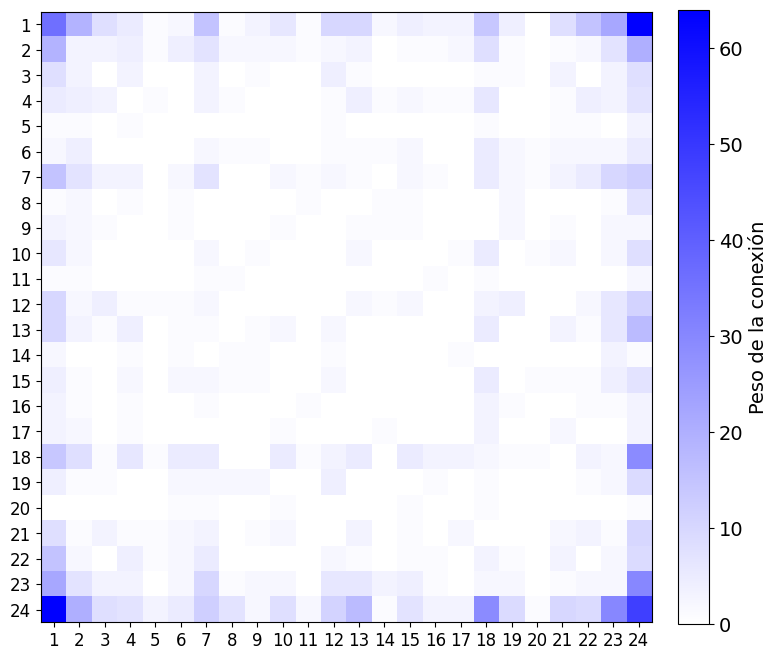

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

C = nx.adjacency_matrix(G).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})
fig, ax = plt.subplots(figsize=(8, 8))
azul_personalizado = LinearSegmentedColormap.from_list(
    'azul_personalizado',
    [(1, 1, 1), (0, 0, 1)]  # Blanco → Azul
)

im = ax.imshow(C, cmap=azul_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Peso de la conexión', fontsize=14)

plt.tight_layout()
plt.show()

In [6]:
from matplotlib.colors import ListedColormap

A = np.array(A, dtype=int)
#A1 = np.array(A1, dtype=int)
print("NIÑO 3.4")
print(A)

cmap = ListedColormap(['white', 'blue'])
#plt.imshow(A, cmap=cmap, interpolation='nearest')

#plt.imshow(A, cmap='gray_r', interpolation='nearest')

NIÑO 3.4
[[36 19  8  5  1  2 15  1  3  6  1 10 10  2  4  3  3 14  4  0  8 15 22 64]
 [19  3  3  4  1  4  7  2  2  2  1  2  3  0  1  1  2  8  1  0  1  2  7 20]
 [ 8  3  0  3  0  0  3  0  1  0  0  4  1  0  0  0  0  1  1  0  3  0  3  8]
 [ 5  4  3  0  1  0  3  1  0  0  0  1  4  1  2  1  1  6  0  0  1  4  3  7]
 [ 1  1  0  1  0  0  0  0  0  0  0  1  0  0  0  0  0  1  0  0  1  1  0  3]
 [ 2  4  0  0  0  0  2  1  1  0  0  1  1  1  2  0  0  5  2  1  2  2  2  5]
 [15  7  3  3  0  2  7  0  0  2  1  2  1  0  2  1  0  5  2  1  3  5 10 12]
 [ 1  2  0  1  0  1  0  0  0  0  1  0  0  1  1  0  0  0  2  0  0  0  1  7]
 [ 3  2  1  0  0  1  0  0  0  1  0  0  1  1  1  0  0  0  2  0  1  0  2  2]
 [ 6  2  0  0  0  0  2  0  1  0  0  0  2  0  0  0  1  5  0  1  2  0  2  8]
 [ 1  1  0  0  0  0  1  1  0  0  0  0  0  0  0  1  0  1  0  0  0  0  0  2]
 [10  2  4  1  1  1  2  0  0  0  0  0  2  1  2  0  0  3  4  0  0  2  6 11]
 [10  3  1  4  0  1  1  0  1  2  0  2  0  0  0  0  0  5  0  0  3  1  6 17]
 [ 2  0  0  1  0

In [7]:
nodos_activos = contar_nodos_activos(G)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 24 de 24 posibles
Porcentaje: 100.00%


#Mapeo anomalias caudal calamar

len() de nodos es 801
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
len() de unique_nodes es 24


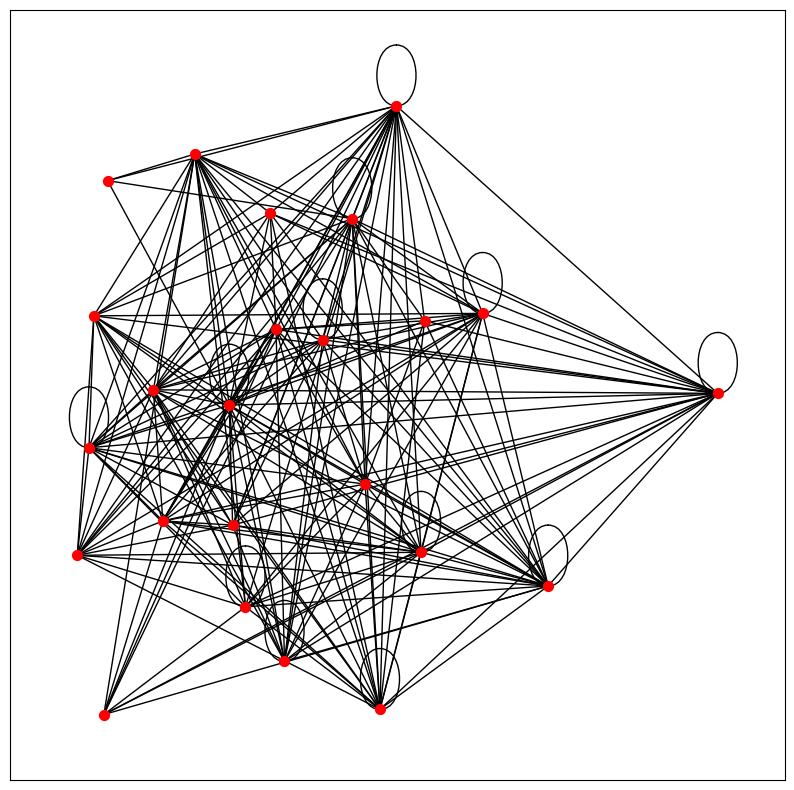

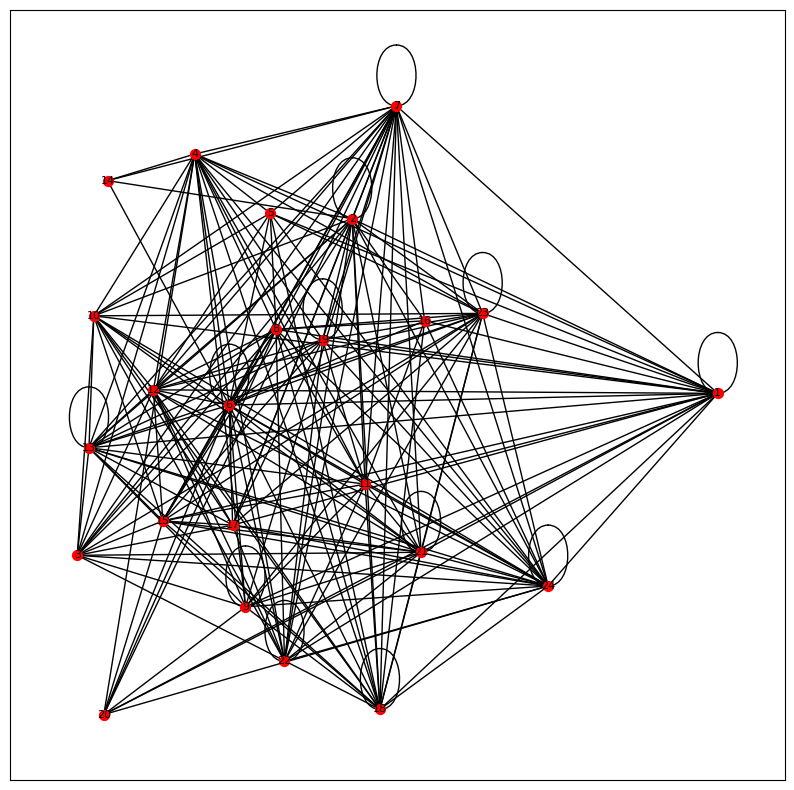

El grado medio de la red es: 16.916666666666668
La distancia minima promedio de la red es: 1.3079710144927537
la distancia maxima es: 2
[[16. 11.  0.  9.  3.  7. 14.  3.  3.  7.  2. 11.  8.  0.  6.  6.  3. 20.
   2.  6. 14.  7. 16. 46.]
 [11.  2.  4.  4.  0.  0.  6.  0.  0.  4.  1.  4.  6.  1.  5.  1.  2. 15.
   1.  0.  3.  5.  4. 19.]
 [ 0.  4.  0.  3.  0.  1.  2.  2.  1.  2.  0.  1.  1.  0.  1.  0.  1.  2.
   0.  0.  3.  0.  6.  6.]
 [ 9.  4.  3.  0.  1.  3.  7.  1.  3.  1.  2.  3.  7.  1.  0.  0.  0.  4.
   1.  2.  2.  3.  3. 13.]
 [ 3.  0.  0.  1.  0.  1.  1.  1.  0.  1.  0.  1.  0.  0.  0.  0.  0.  3.
   0.  0.  0.  0.  1.  7.]
 [ 7.  0.  1.  3.  1.  1.  3.  1.  1.  3.  1.  1.  1.  1.  1.  1.  1.  4.
   1.  2.  2.  4.  4.  8.]
 [14.  6.  2.  7.  1.  3.  4.  5.  2.  3.  2.  6.  4.  3.  3.  1.  2.  7.
   2.  3.  4.  4.  7. 20.]
 [ 3.  0.  2.  1.  1.  1.  5.  0.  0.  0.  1.  2.  3.  0.  1.  1.  0.  3.
   0.  3.  0.  3.  3.  5.]
 [ 3.  0.  1.  3.  0.  1.  2.  0.  2.  0.  1.  2.  1.  0

In [8]:

w_opt=4
x1 = [
    -0.252356095, 1.052095792, 1.666183254, 0.8075340031, 0.4538807798,
    0.8608179653, 1.68047628, 1.761129254, 1.522839038, 0.5967106012,
    0.4271502863, 0.7382952786, 0.8036001207, 1.456365872, 0.8461511547,
    -0.330657103, -0.5696843323, -0.6769169818, -0.4123862702, -0.2917012327,
    -0.1842309045, -0.6312073671, -0.7976322228, -0.4013414609, -0.2668875374,
    -0.5893254678, -0.7762863577, -0.8678600548, -0.270959649, -0.6817542891,
    -0.4636584037, -0.2364320509, -0.578495707, -0.7613636376, -1.033510012,
    -0.6743226767, -0.2498585033, 0.004294667141, -0.6614597729, -0.3454179472,
    -0.6211624496, -0.4593360745, -0.7077973163, -1.111145481, -1.169633441,
    -0.7993732921, -0.8049053182, -0.5717955062, -0.0149997409, -0.4136024938,
    -0.4389171073, -0.4062713757, -0.1469796532, -0.1737782698, 0.8207015265,
    1.466418235, 0.7622997686, 0.4811315691, 0.5415707575, 0.6737521503,
    1.079129893, 0.2921049213, 0.275216807, 1.150577042, 1.004377823,
    0.7372805789, 1.033818382, 1.387220675, 1.238946325, 1.036682659,
    0.7235162661, 0.7380628304, 1.618524549, 2.313483234, 2.087912075,
    1.18147539, 0.253898661, 0.7685761945, 0.9116631864, 0.4277464148,
    0.4203830569, 0.6046588239, 0.6900357535, 0, 0.5207762455, -0.1866418801,
    -0.2219892086, -0.4884630194, -0.7428906959, -0.1714673295, -0.7856018826,
    -1.030588713, -1.206624145, -1.180953946, -1.393604169, -1.517494929,
    -1.473224315, -1.170197838, -1.156686813, -1.173580338, -0.8490796403,
    -1.025301029, -1.573032107, -0.8884408656, -1.263431878, -1.498404644,
    -1.372848004, -1.88422727, -1.562300355, -1.49342898, -1.319749768,
    -1.43593586, -0.7383871966, -0.813654146, -0.5216026179, -0.6486039101,
    -0.679851211, -0.6675350326, -0.4000082181, -0.4244783091, -0.1074106328,
    0.1882509602, -0.3046229292, -0.1917165142, 0.020340949, -0.1825911778,
    -0.06076138596, -0.1288175646, 0.09615896201, -0.515793236, -0.2734968586,
    0.1887811378, 0.215800435, -0.1206877059, -0.7494551357, -0.4351812157,
    -0.825135293, -1.418944254, -0.9095809881, -0.7586365219, -0.3982288616,
    -0.5646203888, -0.1121556411, 0.3976286341, 0.05982867325, -0.2564862937,
    -0.08415128414, -0.1128390496, 0.244222826, 0.6014442896, 0.9912448956,
    1.124877767, 0.7862845351, 0.299559202, 0.03060627716, -0.1980367303,
    -0.4207732425, -0.01014194378, 0.3449871887, 1.068869779, 0.9570241974,
    0.7086484198, 0.4461140844, 0.4127161054, -0.07749139603, -0.41061945,
    -0.4458742812, -0.2966727672, -0.7470779182, -1.07683597, -0.9772443868,
    -0.6508577994, -0.8789320436, -0.2841354627, 0.6268526422, 1.232350011,
    1.232929862, 0.7216889837, 0.3518205932, -0.3290335615, -0.6120660593,
    -0.781151412, -0.8950478816, -0.7584411544, -0.7082226697, -1.064626183,
    -1.516163532, -1.068725554, -0.8322412385, -0.7049180638, -0.6862408017,
    0.001628810571, 0.3472645785, -0.2397110417, -0.7377423638, -1.07565909,
    -1.103170633, -0.4321923177, 0.3154628983, 0.4183900077, 0.3384067252,
    0.006893106945, -0.1283387001, 0.3399054872, 1.291921865, 1.001027968,
    0.3254275501, -0.22177357, -0.1552955205, 0.004712494308, 0.3060471584,
    0.03044681763, -0.2773157994, -0.7480066657, -0.6787652072, -0.7259431825,
    -1.000895672, -0.5354157601, -0.4434503412, -0.2271782314, -0.3923311824,
    -0.2244622831, 0.2893201899, 0.4029803845, 0.4530925052, 0.3808553395,
    0.2497272593, 0.226306782, -0.3125963032, -0.2489081973, -0.3556160578,
    0.1634615195, 0.5459349791, 0.2415447096, -0.2398475125, -0.3853443274,
    -0.1038113933, 0.3121081595, 0.6281813421, 0.7652427783, 0.9398891572,
    0.7690977419, 0.2833167985, -0.004006503984, 0.1861232272, 0.4803941017,
    0.371910571, 0.8234181236, 1.208199119, 1.261409588, 0, 0, 1.701853289,
    2.876752988, 2.800366162, 3.106095722, 2.124143921, 1.927140669, 1.41499996,
    1.149612188, 1.44749541, 1.390906255, 1.066625805, 0.3542522926,
    0.09590184389, 0.8868625849, 0.1410376855, 0.3445431713, 0.7401873984,
    0.9984951731, 0.7382826241, -0.4235127786, -0.4991627268, -0.7888361254,
    -0.9535734624, -1.020325633, -1.251435337, -1.305636635, -1.31638551,
    -1.541428733, -1.636166454, -1.612181951, -0.7041650855, -0.001763245984,
    0.7361095064, 1.420951197, 1.253600044, 1.226524066, 1.535195809,
    1.751911631, 1.640962826, 0.9422936274, 0.5261597128, -0.1352169011,
    -0.3621741868, -0.1939489052, -0.1456509454, 1.021891049, 2.306325754,
    1.845830166, 0.004342403704, -0.3966248595, 0.533150913, -0.5612219994,
    -0.4660146721, -0.236036569, 0.3406235014, 0.8680507142, 1.49901644,
    2.098215632, 2.486119709, 2.078405879, 1.509084623, 0.9717980566,
    0.9050831955, 0.7723272227, 0.691540689, 0.07053512523, -0.279443505,
    -0.8951262713, -1.479992102, -0.7079522401, -0.4443049126, -1.283858953,
    -1.703769056, -1.504668478, -1.566587806, -1.547419749, -1.470874656,
    -0.8293019539, -0.8284092036, -0.5081629752, -0.9172987776, -0.1632021585,
    0.2065274353, 0.001712791871, -0.8175639287, -1.09129119, -1.035647167,
    0.7192748621, 1.021722983, 0.4975890645, 0.3382072105, -0.2034317502,
    -0.5170012955, -0.3398604792, -0.2021158995, -0.3261921942, -0.6747470958,
    -1.059921919, -0.5791251997, -0.549724347, 0.04573444212, 0.3743846101,
    0.3798765364, -0.2428171666, 0.2778853266, 0.2780891064, 0.4776569555,
    1.057189771, 0.2190501424, 0.09211234339, -0.7064469419, -1.242260328,
    -1.214398146, -0.911536178, -1.018236133, -0.568695136, -0.7198906894,
    -0.2978602231, -0.4459755308, -0.5170816893, -0.1395387439, -0.4503236552,
    0.5850184725, 0.01985558613, 1.914441378, 3.139444299, 2.688806155,
    1.680746338, 1.326955336, 0.6805791925, 0.6219038677, 0.7265413958,
    0.5806616822, 0.8281934015, 0.7068865272, 1.066677322, 1.472563385,
    1.706485036, 0.7571764599, -0.2584638609, -0.7746713122, -0.4494700991,
    -0.2635406492, -1.010583802, -1.128769527, -1.271254114, -1.023175021,
    -0.3848311858, 0.2926020008, 0.01001982337, -0.7935054921, -0.7790088339,
    -0.5549001456, -0.6976129545, -0.9681871528, -1.047591562, 0.01822106652,
    0.7932859275, 0.6189141758, -0.2772988181, -0.07771048449, 0.573987185,
    1.159792876, 1.467145254, 1.214637221, 1.381803726, 1.439089288,
    1.129371698, 0.4175377261, -0.3731035277, -0.8188343247, -0.7659108044,
    -0.9502969, -1.16405537, -1.58149692, -0.6672851148, 0.1099433106,
    0.2517379446, -0.006535446489, -0.06572419208, -0.2109329695, 0.3700671176,
    1.083306021, 1.205464948, 1.002705732, 0.6117260157, 0.3451443037,
    -0.5953261257, -0.6936842102, -0.1041346606, 0.3584018164, -0.1350227615,
    -0.8490250692, -0.1812000423, -0.02494310725, -0.401784487, -0.5163334728,
    -0.7081342605, -0.9944785373, 0.07032218097, 0.01818819983, 0.1675725317,
    0.5906008702, 0.5324606114, -0.2147928839, -0.0724175659, 0.002394364234,
    -0.2148647811, -0.8093061621, -1.040890084, 0.3061095143, 1.101881868,
    1.899070669, 2.197238615, 1.640440967, 1.573380832, 2.005381632,
    1.709433815, 1.406431252, 0.6780260781, -0.2988947209, -0.3768864237,
    -0.3791973458, -0.2604078441, 0.332049708, 0.9898508069, 1.076244516,
    0.3491434302, -0.1459388225, 0.3446568835, 0.3820354456, 0.2296941158,
    0.3485390282, -0.2820007805, -0.4409920364, -0.5317594546, -0.4913461903,
    -0.3047530802, -0.01438228951, 0.1254172469, 0.01975367959, -0.5121852076,
    0.004166237386, -0.1012649162, -0.3304192154, -0.6210627291, -0.6103350545,
    -0.5259907239, -1.079727054, -0.4222449625, -0.8501638838, -0.6364891011,
    -1.07907313, -0.9077466409, -0.9022734422, -1.63035071, -1.57534692,
    -1.574834805, -1.500060123, -0.8341199683, -0.7495351472, -0.8621015897,
    -1.521718647, -1.218549495, -0.8330177772, -0.4150191706, -0.4005341928,
    0.2219440352, 0.3604220237, 0.223057187, -0.1122985321, -0.5610298362,
    -0.1843768564, -0.167027859, -0.474629164, 0.04650281857, 0.4573572842,
    0.4059112887, 0.7114657838, 1.128550498, 0.8136479426, 0.5253791012,
    0.1804623886, -0.2714079443, -0.506330588, -0.344477704, -0.1917209419,
    0.01794917655, -0.773387776, -1.243797569, -1.088734327, -0.983958301,
    -0.7425785722, -0.5602928321, -0.1262818412, 0.7006310852, 0.9133762288,
    0.2904236928, 0.0547205539, -0.2412451092, -0.08066085834, 0.2976987397,
    1.236722622, 1.26267278, 0.2159756304, 0.6093563226, 1.462437206,
    1.813427144, 1.273569365, 0.6654742712, 0.2992214326, -0.2180382766,
    -0.5776532195, 0.267076965, -0.3277723369, -0.9729195349, -1.599179795,
    -1.615139171, -1.419106584, -1.80879839, -1.924253548, -1.81733945,
    -2.155591689, -2.206715462, -1.926437868, -1.110584979, -1.15233767,
    -0.6488437982, -0.2643381675, -0.1054096877, 0.305096231, 0.434526649,
    0.420918214, 0.3643157805, 0.03085940113, 0.4838074449, 1.251052183,
    1.766483164, 2.801838888, 2.642595017, 1.684718329, 1.257633838,
    1.441516804, 1.132890771, 0.9625944616, 1.451672232, 1.750938017,
    1.352929919, 1.674706171, 0.9973090943, 1.303731643, 0.5001566308,
    0.01813378849, 0.4605356822, 0.7587197682, 0.5593683038, 0.4651740813,
    0.8382739112, 0.3293431848, -0.3220771105, -0.7767793919, -0.9753710514,
    -0.6140103906, -0.9289174328, -1.617595094, -1.360093613, -1.504487391,
    -1.5321838, -1.472516121, -1.209283918, -1.10642659, -0.5933087159,
    -0.1265115327, -0.7450373977, -0.8955771424, -0.3501087854, -0.650613551,
    -0.3548933221, -0.6051595154, -1.460050959, -1.474721616, -1.789504181,
    -1.178398171, -1.596521333, -1.530016144, -1.223951502, -1.044943748,
    -0.8882040163, -0.6478044376, -0.6083917257, -0.1403898621, -0.2499451051,
    -0.7180743987, -0.3563340778, 0.04867932851, 0.5386612307, 0.5940010923,
    -0.4947500805, -0.8798143748, -1.045627527, -0.6115980874, -0.369973187,
    -0.8734457477, -0.724545694, -0.6541312383, -0.2797870859, 0.1220346546,
    0.5212771016, 0.03244031002, 0.0371480761, -0.2214599477, -0.4034925639,
    -0.18434532, 0.1447006424, 0.1304217839, -0.3706143081, -0.6314276054,
    -0.5541162022, 0.07132548623, 1.212835114, 0.9675897194, 0.6436206563,
    0.1285425281, 1.006461235, 1.286180942, 1.680183402, 1.042111716,
    -0.2138628798, -0.2715425899, -0.7034999162, -0.407635687, 0.2910143737,
    0.3978408099, -0.4758463241, -0.8794001706, 0.5217752765, 1.068207121,
    1.807187199, 1.496514702, 0.9230670201, 1.363864956, 0.9456738592,
    1.625827277, 1.130799381, 0.8493230773, 0.5872218778, 0.9069241027,
    0.5334768784, 0.5629457212, 1.049903803, 1.701883837, 2.212560092,
    2.193536788, 1.760449144, 1.723212505, 1.967085167, 1.430836211,
    1.428054823, 1.065541267, 1.508100495, 0.6590129397, -0.2349398516,
    -0.2906519768, -0.6789648189, -0.7459674335, -1.689574243, -1.415659704,
    -1.623451336, -1.5651811, -1.215509008, -0.6611836369, -0.3298158113,
    0.1975157425, 0.6391243676, 1.434985024, 2.606983226, 2.541242926,
    2.602020823, 1.922657317, 1.751799104, 1.946702419, 1.392390548,
    1.745158172, 2.522290312, 3.524576116, 2.726079744, 1.557779367,
    1.325534768, 0.7366284465, 0.4961870202, 0.7502377197, 1.514257997,
    1.905123194, 1.54808697, 0.2794278821, 1.230831166, 1.915622989,
    0.4779069032, -0.7659130092, -0.6011738802, -0.5420401592, -1.114762729,
    -1.043516846, -1.32330217, -1.467647307, -0.8212681003, -0.2547573562,
    -0.571241018, -0.4404874117, 0.02443382407, -0.6541400698, -0.9093505388,
    -0.1199634065, -0.380343647, -0.7010401164, -0.6498561247, -0.5314477735,
    -0.4649626485, 0.2870216242, -0.6887159231, -0.2908686827, -0.9046425255,
    -1.574871606, -1.579092274, -1.031789955, -0.7951023591, -0.8091578009,
    -0.6197068379, -1.065918201, -0.3272526715, -0.5348974049, -0.07536333116,
    -1.243381062, -1.341371079, -1.769546706, -1.613515001, -1.567255137,
    -2.173047155, -2.084227605, -2.369191284, 0, -1.310538786, -1.054061991,
    -0.7036169826, -0.5123204537, -1.382262973, -1.255341301, -0.9216495913,
    -0.5531892647, 0, -0.5293208162, 0.1494266392
]
nodos1 = crear_ind(x1 , w_opt)
print("len() de nodos es",len(nodos1))

G1, unique_nodes1, nodo_a_sublista1= crear_grafo(nodos1, w_opt)
A1 = nx.to_numpy_array(G1)
print(unique_nodes1)
print("len() de unique_nodes es",len(unique_nodes1))
# Dibujar el grafo
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G1)  # Layout para la visualización
nx.draw_networkx_nodes(G1, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G1, pos, edge_color="black")
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G1)
nx.draw_networkx_nodes(G1, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G1, pos, edge_color="black")
labels = {i: i+1 for i in G1.nodes()}
nx.draw_networkx_labels(G1, pos, labels, font_size=8)
plt.show()
#nx.draw_networkx_labels(G, pos, {i: f"{i}" for i in G.nodes()}, font_size=8)
#MU,MUT,MC=calcular_entropia(unique_nodes,nodos)
#for i in range(len(MC)):
 #   print(MC[i])
#plt.title("Grafo")
def calcular_grado_medio(G1):
    grados = [grado for _, grado in G1.degree()]  # Obtener los grados de todos los nodos
    grado_medio = np.mean(grados)  # Calcular el grado medio
    return grado_medio
#G, unique_nodes = crear_grafo(nodos, w_opt)
grado_medio = calcular_grado_medio(G1)
distancia_media=nx.average_shortest_path_length(G1)
print(f"El grado medio de la red es: {grado_medio}")
print((f"La distancia minima promedio de la red es: {distancia_media}"))
print("la distancia maxima es:",nx.diameter(G1))
print(A1)
plt.show()

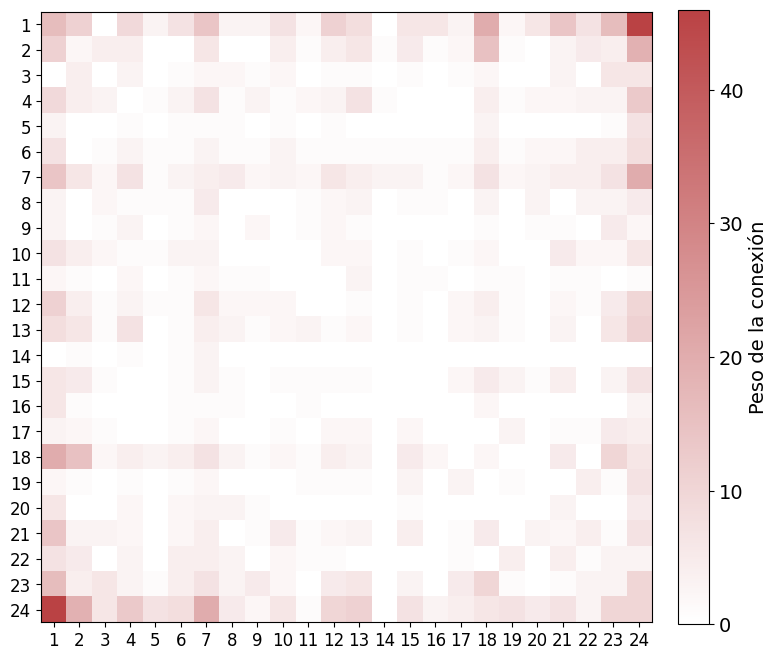

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap,to_rgb

C = nx.adjacency_matrix(G1).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})
fig, ax = plt.subplots(figsize=(8, 8))
# Blanco → Verde
color_hex = '#ba4244'  # Cambia este valor por el hexadecimal que desees
verde_personalizado = LinearSegmentedColormap.from_list(
    'verde_personalizado',                # nombre del mapa
    [(1, 1, 1), to_rgb(color_hex)]        # blanco → color hexadecimal
)


im = ax.imshow(C, cmap=verde_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Peso de la conexión', fontsize=14)

plt.tight_layout()
plt.show()

In [10]:
print(unique_nodes)
print(nodo_a_sublista)
print(unique_nodes1)
print(nodo_a_sublista1)

{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
{0: (1, 2, 3, 4), 1: (1, 2, 4, 3), 2: (1, 3, 2, 4), 3: (1, 3, 4, 2), 4: (1, 4, 2, 3), 5: (1, 4, 3, 2), 6: (2, 1, 3, 4), 7: (2, 1, 4, 3), 8: (2, 3, 1, 4), 9: (2, 3, 4, 1), 10: (2, 4, 1, 3), 11: (2, 4, 3, 1), 12: (3, 1, 2, 4), 13: (3, 1, 4, 2), 14: (3, 2, 1, 4), 15: (3, 2, 4, 1), 16: (3, 4, 1, 2), 17: (3, 4, 2, 1), 18: (4, 1, 2, 3), 19: (4, 1, 3, 2), 20: (4, 2, 1, 3), 21: (4, 2, 3, 1), 22: (4, 3, 1, 2), 23: (4, 3, 2, 1)}
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, 

In [11]:
nodos_activos = contar_nodos_activos(G1)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 24 de 24 posibles
Porcentaje: 100.00%


## W OPTIMO

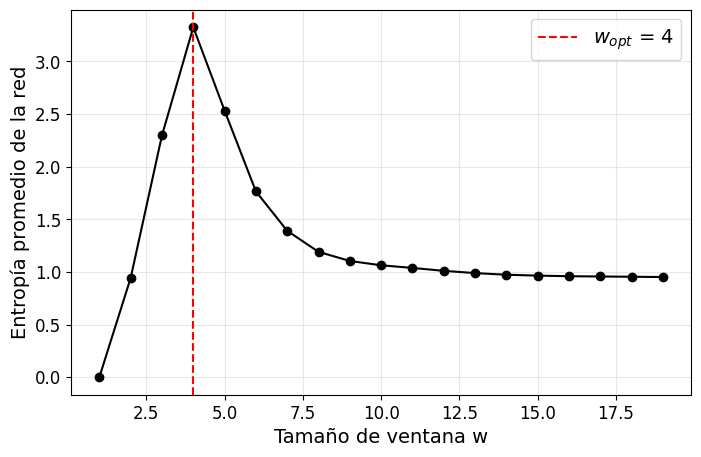

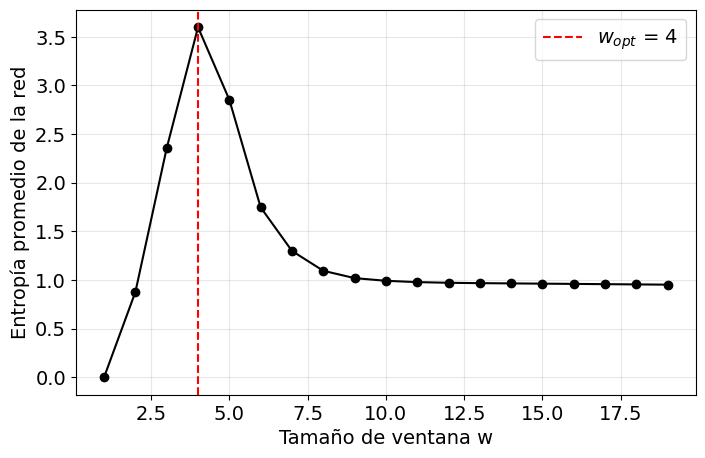

4
4


In [12]:
ventana=optimizar_w(x,1,20)
ventana1=optimizar_w(x1,1,20)
print(ventana)
print(ventana1)

##INTERSECCIÓN

NIÑO 3.4
[[36 19  8  5  1  2 15  1  3  6  1 10 10  2  4  3  3 14  4  0  8 15 22 64]
 [19  3  3  4  1  4  7  2  2  2  1  2  3  0  1  1  2  8  1  0  1  2  7 20]
 [ 8  3  0  3  0  0  3  0  1  0  0  4  1  0  0  0  0  1  1  0  3  0  3  8]
 [ 5  4  3  0  1  0  3  1  0  0  0  1  4  1  2  1  1  6  0  0  1  4  3  7]
 [ 1  1  0  1  0  0  0  0  0  0  0  1  0  0  0  0  0  1  0  0  1  1  0  3]
 [ 2  4  0  0  0  0  2  1  1  0  0  1  1  1  2  0  0  5  2  1  2  2  2  5]
 [15  7  3  3  0  2  7  0  0  2  1  2  1  0  2  1  0  5  2  1  3  5 10 12]
 [ 1  2  0  1  0  1  0  0  0  0  1  0  0  1  1  0  0  0  2  0  0  0  1  7]
 [ 3  2  1  0  0  1  0  0  0  1  0  0  1  1  1  0  0  0  2  0  1  0  2  2]
 [ 6  2  0  0  0  0  2  0  1  0  0  0  2  0  0  0  1  5  0  1  2  0  2  8]
 [ 1  1  0  0  0  0  1  1  0  0  0  0  0  0  0  1  0  1  0  0  0  0  0  2]
 [10  2  4  1  1  1  2  0  0  0  0  0  2  1  2  0  0  3  4  0  0  2  6 11]
 [10  3  1  4  0  1  1  0  1  2  0  2  0  0  0  0  0  5  0  0  3  1  6 17]
 [ 2  0  0  1  0

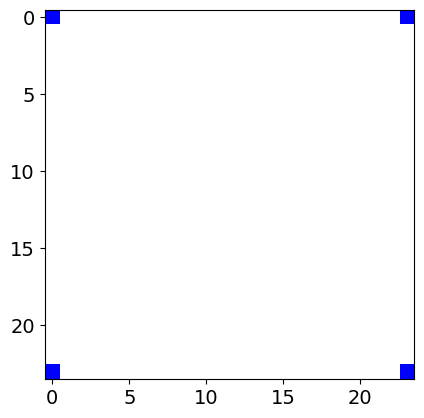

In [13]:
from matplotlib.colors import ListedColormap

A = np.array(A, dtype=int)
A1 = np.array(A1, dtype=int)
print("NIÑO 3.4")
print(A)

# contar diagonal (loops)
loops = np.count_nonzero(np.diag(A))

# contar fuera de la diagonal
off_diag = np.count_nonzero(A) - loops

# calcular M
M = off_diag / 2 + loops

print("M =", M)

cmap = ListedColormap(['white', 'blue'])
plt.imshow(A, cmap=cmap, interpolation='nearest')
#plt.imshow(A, cmap='gray_r', interpolation='nearest')



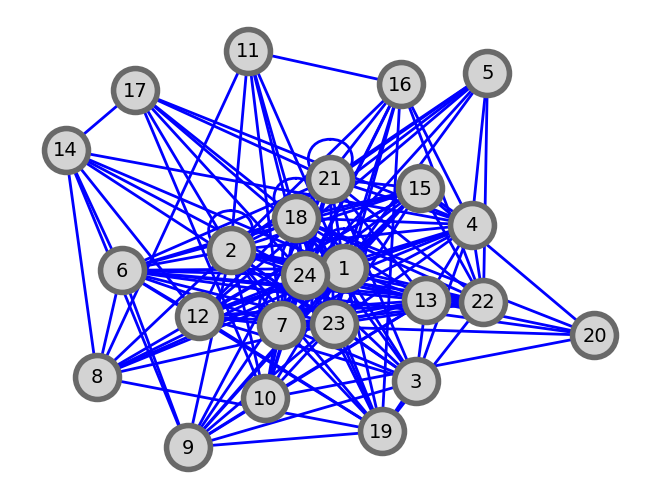

In [14]:
G = nx.from_numpy_array(A)
pos = nx.spring_layout(G, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in G.nodes()}

nx.draw(
    G, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='blue',
    width=2,
    font_size=14
)
plt.show()

CALAMAR
[[16 11  0  9  3  7 14  3  3  7  2 11  8  0  6  6  3 20  2  6 14  7 16 46]
 [11  2  4  4  0  0  6  0  0  4  1  4  6  1  5  1  2 15  1  0  3  5  4 19]
 [ 0  4  0  3  0  1  2  2  1  2  0  1  1  0  1  0  1  2  0  0  3  0  6  6]
 [ 9  4  3  0  1  3  7  1  3  1  2  3  7  1  0  0  0  4  1  2  2  3  3 13]
 [ 3  0  0  1  0  1  1  1  0  1  0  1  0  0  0  0  0  3  0  0  0  0  1  7]
 [ 7  0  1  3  1  1  3  1  1  3  1  1  1  1  1  1  1  4  1  2  2  4  4  8]
 [14  6  2  7  1  3  4  5  2  3  2  6  4  3  3  1  2  7  2  3  4  4  7 20]
 [ 3  0  2  1  1  1  5  0  0  0  1  2  3  0  1  1  0  3  0  3  0  3  3  5]
 [ 3  0  1  3  0  1  2  0  2  0  1  2  1  0  0  0  0  1  0  1  1  0  5  2]
 [ 7  4  2  1  1  3  3  0  0  0  0  2  2  0  1  0  1  2  0  0  5  2  2  6]
 [ 2  1  0  2  0  1  2  1  1  0  0  0  3  0  1  1  0  1  1  0  1  1  0  1]
 [11  4  1  3  1  1  6  2  2  2  0  0  1  0  1  0  2  4  1  0  2  1  5 10]
 [ 8  6  1  7  0  1  4  3  1  2  3  1  2  0  1  0  2  3  1  0  3  0  6 11]
 [ 0  1  0  1  0 

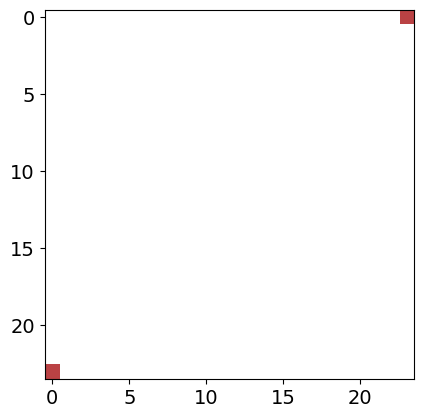

In [15]:
print("CALAMAR")
print(A1)
cmap = ListedColormap(['white', '#ba4244'])

# contar diagonal (loops)
loops = np.count_nonzero(np.diag(A1))

# contar fuera de la diagonal
off_diag = np.count_nonzero(A1) - loops

# calcular M
M = off_diag / 2 + loops

print("M =", M)

plt.imshow(A1, cmap=cmap, interpolation='nearest')


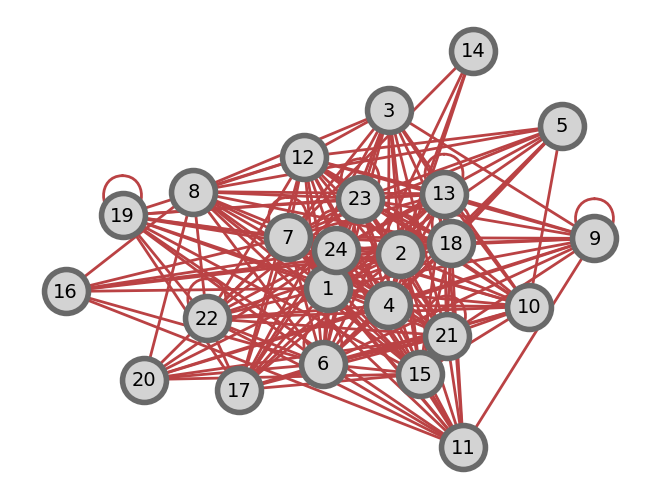

In [16]:
G1 = nx.from_numpy_array(A1)
pos = nx.spring_layout(G1, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in G1.nodes()}

nx.draw(
    G1, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='#ba4244',
    width=2,
    font_size=14
)
plt.show()

In [17]:
print(A.shape, A1.shape)

(24, 24) (24, 24)


##INTERSECCIÓN


In [18]:
C = np.divide(A1 ,A, out=np.zeros_like(A, dtype=float), where=A!=0) * 100
C_clean = np.where(np.isinf(C), 0, C)
#print(C_clean)
C_clean_beauty = np.array(C_clean, dtype=int)
print(C_clean_beauty)

[[ 44  57   0 180 300 350  93 300 100 116 200 110  80   0 150 200 100 142
   50   0 175  46  72  71]
 [ 57  66 133 100   0   0  85   0   0 200 100 200 200   0 500 100 100 187
  100   0 300 250  57  95]
 [  0 133   0 100   0   0  66   0 100   0   0  25 100   0   0   0   0 200
    0   0 100   0 200  75]
 [180 100 100   0 100   0 233 100   0   0   0 300 175 100   0   0   0  66
    0   0 200  75 100 185]
 [300   0   0 100   0   0   0   0   0   0   0 100   0   0   0   0   0 300
    0   0   0   0   0 233]
 [350   0   0   0   0   0 150 100 100   0   0 100 100 100  50   0   0  80
   50 200 100 200 200 160]
 [ 93  85  66 233   0 150  57   0   0 150 200 300 400   0 150 100   0 140
  100 300 133  80  70 166]
 [300   0   0 100   0 100   0   0   0   0 100   0   0   0 100   0   0   0
    0   0   0   0 300  71]
 [100   0 100   0   0 100   0   0   0   0   0   0 100   0   0   0   0   0
    0   0 100   0 250 100]
 [116 200   0   0   0   0 150   0   0   0   0   0 100   0   0   0 100  40
    0   0 250   0

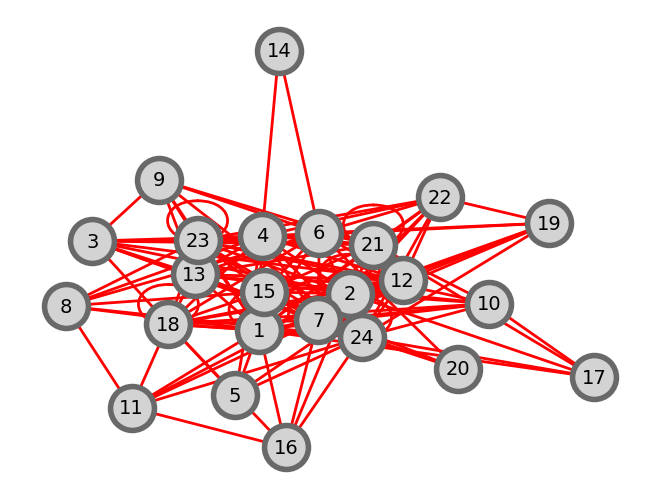

In [19]:
GC = nx.from_numpy_array(C_clean)
pos = nx.spring_layout(GC, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in GC.nodes()}

nx.draw(
    GC, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='red',
    width=2,
    font_size=14
)
plt.show()

INTERCEPCIÓN
M = 142.0


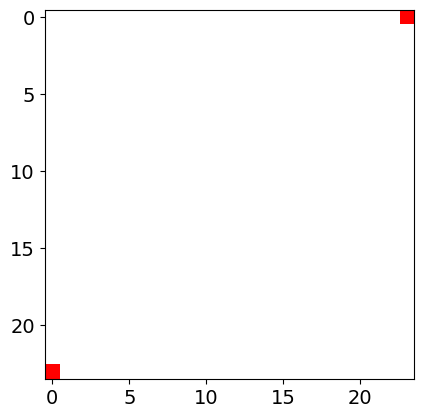

In [20]:
print("INTERCEPCIÓN")
#print(C_clean)
cmap = ListedColormap(['white', 'red'])

# contar diagonal (loops)
loops = np.count_nonzero(np.diag(C_clean))

# contar fuera de la diagonal
off_diag = np.count_nonzero(C_clean) - loops

# calcular M
M = off_diag / 2 + loops

print("M =", M)

plt.imshow(A1, cmap=cmap, interpolation='nearest')

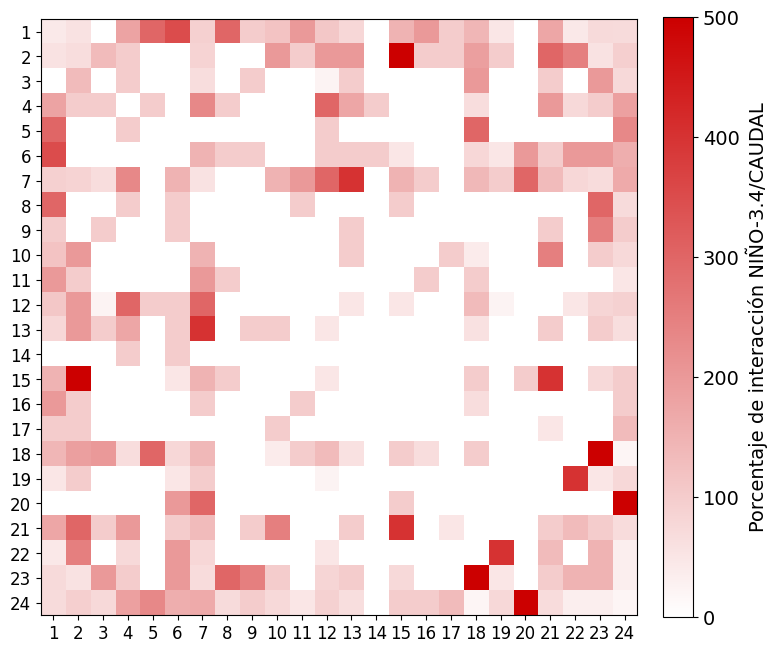

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

C = nx.adjacency_matrix(GC).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})
fig, ax = plt.subplots(figsize=(8, 8))
# Blanco → Rojo
rojo_personalizado = LinearSegmentedColormap.from_list(
    'rojo_personalizado',
    [(1, 1, 1), (0.8, 0, 0)]  # Blanco → Rojo
)

im = ax.imshow(C, cmap=rojo_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Porcentaje de interacción NIÑO-3.4/CAUDAL', fontsize=14)

plt.tight_layout()
plt.show()



In [22]:
nodos_activos = contar_nodos_activos(GC)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 24 de 24 posibles
Porcentaje: 100.00%


#PORCENTAJE DE INTERACCIÓN

In [23]:
upper = np.triu(C_clean)
promedio = np.mean(upper)
print("La influencia del NIÑO 3.4 en el caudal es:",promedio,"%")

La influencia del NIÑO 3.4 en el caudal es: 33.67654605363318 %


##MÉTRICAS

In [24]:
import networkx as nx
import numpy as np

# Intento de importar correctamente python-louvain
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def calcular_metricas_red(G, nombre_grafo):
    """
    Calcula e imprime métricas de red considerando solo nodos activos.
    Las etiquetas en pantalla se muestran como 1‑based.
    """
    print(f"\n=== Métricas para {nombre_grafo} ===")

    # Identificar nodos activos (grado > 0)
    nodos_activos = [n for n in G.nodes() if G.degree(n) > 0]
    num_activos = len(nodos_activos)
    print(f"Nodos activos: {num_activos} de {G.number_of_nodes()}")

    if num_activos == 0:
        print("No hay nodos activos. No se pueden calcular métricas.")
        return

    # Subgrafo inducido por los nodos activos
    G_activo = G.subgraph(nodos_activos).copy()

    # ---- Grado medio (solo activos) ----
    grados = [d for n, d in G_activo.degree()]
    grado_medio = np.mean(grados)
    print(f"Grado medio (solo activos): {grado_medio:.4f}")

    # ---- Coeficiente de clustering promedio (solo activos) ----
    clustering = nx.average_clustering(G, nodes=nodos_activos)
    print(f"Coeficiente de clustering promedio (solo activos): {clustering:.4f}")

    # ---- Diámetro y distancia promedio ----
    if nx.is_connected(G_activo):
        diametro = nx.diameter(G_activo)
        dist_prom = nx.average_shortest_path_length(G_activo)
        print(f"Diámetro (componente activa): {diametro}")
        print(f"Distancia promedio (componente activa): {dist_prom:.4f}")
    else:
        componentes = list(nx.connected_components(G_activo))
        comp_gigante = max(componentes, key=len)
        G_gigante = G_activo.subgraph(comp_gigante)
        diametro = nx.diameter(G_gigante)
        dist_prom = nx.average_shortest_path_length(G_gigante)
        print(f"El grafo activo no es conexo. Métricas sobre la componente gigante ({len(comp_gigante)} nodos):")
        print(f"  Diámetro: {diametro}")
        print(f"  Distancia promedio: {dist_prom:.4f}")

    # ---- Modularidad (sobre grafo activo) ----
    # (Requiere python-louvain instalado)
    particion = community_louvain.best_partition(G_activo)
    modularidad = community_louvain.modularity(particion, G_activo)
    print(f"Modularidad (sobre grafo activo): {modularidad:.4f}")

    # ---- Centralidades ----
    # Centralidad de grado (solo activos)
    cent_grado = nx.degree_centrality(G_activo)
    prom_cent_grado = np.mean(list(cent_grado.values()))
    print(f"Centralidad de grado promedio (activos): {prom_cent_grado:.4f}")

    # Top 3 nodos con mayor centralidad de grado (etiquetas 1‑based)
    top_nodos = sorted(cent_grado.items(), key=lambda x: x[1], reverse=True)[:3]
    print("Top 3 nodos activos con mayor centralidad de grado:")
    for nodo, valor in top_nodos:
        print(f"  Nodo {nodo+1}: {valor:.4f}")

    # Centralidad de cercanía (sobre la componente usada)
    if nx.is_connected(G_activo):
        cent_cercania = nx.closeness_centrality(G_activo)
    else:
        cent_cercania = nx.closeness_centrality(G_gigante)
    prom_cent_cercania = np.mean(list(cent_cercania.values()))
    print(f"Centralidad de cercanía promedio (componente usada): {prom_cent_cercania:.4f}")

    # Centralidad de intermediación (betweenness) sobre todo el grafo activo
    cent_inter = nx.betweenness_centrality(G_activo)
    prom_cent_inter = np.mean(list(cent_inter.values()))
    print(f"Centralidad de intermediación promedio (activos): {prom_cent_inter:.4f}")

In [25]:
calcular_metricas_red(G, "NIÑO 3.4")
calcular_metricas_red(G1, "CALAMAR")
calcular_metricas_red(GC, "INTERSECCIÓN")


=== Métricas para NIÑO 3.4 ===
Nodos activos: 24 de 24
Grado medio (solo activos): 14.5000
Coeficiente de clustering promedio (solo activos): 0.7481
Diámetro (componente activa): 2
Distancia promedio (componente activa): 1.3949
Modularidad (sobre grafo activo): 0.0778
Centralidad de grado promedio (activos): 0.6304
Top 3 nodos activos con mayor centralidad de grado:
  Nodo 24: 1.0870
  Nodo 1: 1.0435
  Nodo 2: 1.0000
Centralidad de cercanía promedio (componente usada): 0.7337
Centralidad de intermediación promedio (activos): 0.0180

=== Métricas para CALAMAR ===
Nodos activos: 24 de 24
Grado medio (solo activos): 16.9167
Coeficiente de clustering promedio (solo activos): 0.8108
Diámetro (componente activa): 2
Distancia promedio (componente activa): 1.3080
Modularidad (sobre grafo activo): 0.0780
Centralidad de grado promedio (activos): 0.7355
Top 3 nodos activos con mayor centralidad de grado:
  Nodo 7: 1.0870
  Nodo 6: 1.0435
  Nodo 24: 1.0435
Centralidad de cercanía promedio (compon

##MÉTRICAS PESADAS

In [26]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def calcular_metricas_red_pesada(G, nombre_grafo, usar_inverso_para_distancias=True):
    """
    Calcula e imprime métricas de red considerando pesos en las aristas.

    Parámetros:
    - G: grafo de NetworkX con aristas que tienen atributo 'weight'
    - nombre_grafo: título para la salida
    - usar_inverso_para_distancias: si True, usa 1/weight como distancia para caminos;
      si False, ignora los pesos para distancias (trata como no pesado).
    """
    print(f"\n=== Métricas PESADAS para {nombre_grafo} ===")

    # Nodos activos (grado no pesado > 0, pero usaremos fuerza > 0 para activos pesados)
    # Consideramos nodos activos aquellos con fuerza > 0
    fuerzas = dict(G.degree(weight='weight'))
    nodos_activos = [n for n, f in fuerzas.items() if f > 0]
    num_activos = len(nodos_activos)
    print(f"Nodos con fuerza > 0: {num_activos} de {G.number_of_nodes()}")

    if num_activos == 0:
        print("No hay nodos con fuerza positiva. No se pueden calcular métricas.")
        return

    # ---- Grado medio pesado (fuerza promedio) ----
    fuerza_promedio = np.mean(list(fuerzas.values()))
    print(f"Fuerza promedio (grado pesado): {fuerza_promedio:.4f}")

    # ---- Coeficiente de clustering pesado ----
    # Utiliza la definición estándar de clustering pesado de NetworkX
    clustering_pesado = nx.average_clustering(G, weight='weight')
    print(f"Coeficiente de clustering pesado promedio: {clustering_pesado:.4f}")

    # ---- Preparar grafo con distancias (inverso del peso) si se requiere ----
    if usar_inverso_para_distancias:
        # Crear una copia del grafo con atributo 'distance' = 1/weight
        G_dist = nx.Graph()
        for u, v, data in G.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
    else:
        G_dist = G  # usa el grafo original sin considerar pesos para distancias

    # ---- Diámetro y distancia promedio pesados ----
    # Se calculan sobre el subgrafo de nodos activos (para evitar aislados)
    G_activo = G.subgraph(nodos_activos).copy()
    if usar_inverso_para_distancias:
        G_dist_activo = G_dist.subgraph(nodos_activos).copy()
    else:
        G_dist_activo = G_activo

    if nx.is_connected(G_dist_activo):
        diametro = nx.diameter(G_dist_activo, weight='distance' if usar_inverso_para_distancias else None)
        dist_prom = nx.average_shortest_path_length(G_dist_activo, weight='distance' if usar_inverso_para_distancias else None)
        print(f"Diámetro (pesado): {diametro}")
        print(f"Distancia promedio (pesada): {dist_prom:.4f}")
    else:
        componentes = list(nx.connected_components(G_dist_activo))
        comp_gigante = max(componentes, key=len)
        G_gigante = G_dist_activo.subgraph(comp_gigante)
        diametro = nx.diameter(G_gigante, weight='distance' if usar_inverso_para_distancias else None)
        dist_prom = nx.average_shortest_path_length(G_gigante, weight='distance' if usar_inverso_para_distancias else None)
        print(f"El grafo activo no es conexo. Métricas sobre la componente gigante ({len(comp_gigante)} nodos):")
        print(f"  Diámetro (pesado): {diametro}")
        print(f"  Distancia promedio (pesada): {dist_prom:.4f}")

    # ---- Modularidad pesada ----
    # La partición de Louvain puede usar pesos
    particion = community_louvain.best_partition(G, weight='weight')
    modularidad = community_louvain.modularity(particion, G, weight='weight')
    print(f"Modularidad (pesada): {modularidad:.4f}")

    # ---- Centralidades pesadas ----
    # Centralidad de grado pesada (fuerza normalizada)
    # Normalizamos por la suma total de fuerzas de la red (o por el máximo posible)
    total_fuerza = sum(fuerzas.values())
    cent_fuerza = {n: f / total_fuerza for n, f in fuerzas.items()}
    prom_cent_fuerza = np.mean(list(cent_fuerza.values()))
    print(f"Centralidad de fuerza promedio: {prom_cent_fuerza:.6f}")

    # Top 3 nodos con mayor fuerza (etiquetas 1‑based)
    top_nodos = sorted(fuerzas.items(), key=lambda x: x[1], reverse=True)[:3]
    print("Top 3 nodos con mayor fuerza:")
    for nodo, valor in top_nodos:
        print(f"  Nodo {nodo+1}: {valor:.2f}")

    # Centralidad de cercanía pesada (usando distancias inversas)
    if usar_inverso_para_distancias:
        # Usar el grafo con distancias (G_dist)
        cent_cercania = nx.closeness_centrality(G_dist, distance='distance')
        prom_cent_cercania = np.mean(list(cent_cercania.values()))
        print(f"Centralidad de cercanía promedio (pesada, con inverso): {prom_cent_cercania:.6f}")
    else:
        # Versión no pesada (longitudes de camino = 1 por arista)
        cent_cercania = nx.closeness_centrality(G)
        prom_cent_cercania = np.mean(list(cent_cercania.values()))
        print(f"Centralidad de cercanía promedio (no pesada): {prom_cent_cercania:.6f}")

    # Centralidad de intermediación pesada (usando distancias inversas)
    if usar_inverso_para_distancias:
        cent_inter = nx.betweenness_centrality(G_dist, weight='distance')
    else:
        cent_inter = nx.betweenness_centrality(G, weight=None)
    prom_cent_inter = np.mean(list(cent_inter.values()))
    print(f"Centralidad de intermediación promedio: {prom_cent_inter:.6f}")

In [27]:
# Para NIÑO 3.4 (G)
calcular_metricas_red_pesada(G, "NIÑO 3.4")

# Para CAUDAL (G1)
calcular_metricas_red_pesada(G1, "CALAMAR")

# Para INTERSECCIÓN (GC, si existe)
calcular_metricas_red_pesada(GC, "INTERSECCIÓN")


=== Métricas PESADAS para NIÑO 3.4 ===
Nodos con fuerza > 0: 24 de 24
Fuerza promedio (grado pesado): 66.4167
Coeficiente de clustering pesado promedio: 0.0397
Diámetro (pesado): 1.5
Distancia promedio (pesada): 0.3915
Modularidad (pesada): 0.0802
Centralidad de fuerza promedio: 0.041667
Top 3 nodos con mayor fuerza:
  Nodo 24: 364.00
  Nodo 1: 292.00
  Nodo 23: 113.00
Centralidad de cercanía promedio (pesada, con inverso): 3.014412
Centralidad de intermediación promedio: 0.047843

=== Métricas PESADAS para CALAMAR ===
Nodos con fuerza > 0: 24 de 24
Fuerza promedio (grado pesado): 66.4167
Coeficiente de clustering pesado promedio: 0.0588
Diámetro (pesado): 0.8075757575757576
Distancia promedio (pesada): 0.2883
Modularidad (pesada): 0.0769
Centralidad de fuerza promedio: 0.041667
Top 3 nodos con mayor fuerza:
  Nodo 1: 236.00
  Nodo 24: 226.00
  Nodo 7: 119.00
Centralidad de cercanía promedio (pesada, con inverso): 3.821023
Centralidad de intermediación promedio: 0.057806

=== Métricas

In [28]:
import networkx as nx
import numpy as np
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def metricas_formateadas(G_nino, G_caudal, G_interseccion=None, decimales=2):
    """
    Calcula las métricas no pesadas y pesadas para los tres grafos.
    Retorna un diccionario con las siguientes claves:
        'grado_medio', 'clustering', 'diametro', 'distancia_promedio',
        'modularidad', 'cent_grado_prom', 'cent_cercania_prom', 'cent_inter_prom'
    Cada valor es una cadena con el formato:
        "(a,b),(c,d),(e,f)" donde a,b son los valores del primer grafo, etc.
    Si un valor es None, se escribe como "None".
    """
    # ------------------------------------------------------------------------
    # Función auxiliar para métricas no pesadas de un grafo
    # ------------------------------------------------------------------------
    def _no_pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        grados = [d for n, d in G.degree()]
        grado_medio = float(np.mean(grados))
        clustering = float(nx.average_clustering(G))
        if nx.is_connected(G):
            diametro = float(nx.diameter(G))
            dist_prom = float(nx.average_shortest_path_length(G))
        else:
            comps = list(nx.connected_components(G))
            if comps:
                G_gig = G.subgraph(max(comps, key=len)).copy()
                diametro = float(nx.diameter(G_gig))
                dist_prom = float(nx.average_shortest_path_length(G_gig))
            else:
                diametro = dist_prom = None
        try:
            particion = community_louvain.best_partition(G)
            modularidad = float(community_louvain.modularity(particion, G))
        except:
            modularidad = None
        cent_grado = nx.degree_centrality(G)
        prom_cent_grado = float(np.mean(list(cent_grado.values())))
        if nx.is_connected(G):
            cent_cercania = nx.closeness_centrality(G)
            prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
        else:
            prom_cent_cercania = None
        cent_inter = nx.betweenness_centrality(G)
        prom_cent_inter = float(np.mean(list(cent_inter.values())))
        return {
            'grado_medio': grado_medio,
            'clustering': clustering,
            'diametro': diametro,
            'distancia_promedio': dist_prom,
            'modularidad': modularidad,
            'cent_grado_prom': prom_cent_grado,
            'cent_cercania_prom': prom_cent_cercania,
            'cent_inter_prom': prom_cent_inter
        }

    # ------------------------------------------------------------------------
    # Función auxiliar para métricas pesadas de un grafo
    # ------------------------------------------------------------------------
    def _pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        fuerzas = dict(G.degree(weight='weight'))
        fuerza_media = float(np.mean(list(fuerzas.values())))
        clustering_pesado = float(nx.average_clustering(G, weight='weight'))
        G_dist = nx.Graph()
        for u, v, data in G.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
        nodos_activos = [n for n, f in fuerzas.items() if f > 0]
        if not nodos_activos:
            diam_pesado = dist_prom_pesado = None
        else:
            G_activo = G.subgraph(nodos_activos).copy()
            G_dist_activo = G_dist.subgraph(nodos_activos).copy()
            if nx.is_connected(G_dist_activo):
                diam_pesado = float(nx.diameter(G_dist_activo, weight='distance'))
                dist_prom_pesado = float(nx.average_shortest_path_length(G_dist_activo, weight='distance'))
            else:
                comps = list(nx.connected_components(G_dist_activo))
                if comps:
                    G_gig = G_dist_activo.subgraph(max(comps, key=len)).copy()
                    diam_pesado = float(nx.diameter(G_gig, weight='distance'))
                    dist_prom_pesado = float(nx.average_shortest_path_length(G_gig, weight='distance'))
                else:
                    diam_pesado = dist_prom_pesado = None
        try:
            particion_pesada = community_louvain.best_partition(G, weight='weight')
            modularidad_pesada = float(community_louvain.modularity(particion_pesada, G, weight='weight'))
        except:
            modularidad_pesada = None
        total_fuerza = sum(fuerzas.values())
        if total_fuerza > 0:
            cent_fuerza_prom = float(np.mean([f/total_fuerza for f in fuerzas.values()]))
        else:
            cent_fuerza_prom = 0.0
        if nodos_activos:
            cent_cercania_pesada = nx.closeness_centrality(G_dist, distance='distance')
            prom_cent_cercania_pesada = float(np.mean(list(cent_cercania_pesada.values())))
        else:
            prom_cent_cercania_pesada = None
        cent_inter_pesada = nx.betweenness_centrality(G_dist, weight='distance')
        prom_cent_inter_pesada = float(np.mean(list(cent_inter_pesada.values())))
        return {
            'grado_medio': fuerza_media,
            'clustering': clustering_pesado,
            'diametro': diam_pesado,
            'distancia_promedio': dist_prom_pesado,
            'modularidad': modularidad_pesada,
            'cent_grado_prom': cent_fuerza_prom,
            'cent_cercania_prom': prom_cent_cercania_pesada,
            'cent_inter_prom': prom_cent_inter_pesada
        }

    grafos = [G_nino, G_caudal, G_interseccion]
    no_pesadas = [_no_pesadas(g) for g in grafos]
    pesadas = [_pesadas(g) for g in grafos]

    metricas = [
        'grado_medio',
        'clustering',
        'diametro',
        'distancia_promedio',
        'modularidad',
        'cent_grado_prom',
        'cent_cercania_prom',
        'cent_inter_prom'
    ]

    resultado = {}
    for met in metricas:
        pares = []
        for i in range(3):
            val_no = no_pesadas[i][met] if no_pesadas[i] is not None else None
            val_pes = pesadas[i][met] if pesadas[i] is not None else None
            # Formatear los números con la precisión indicada
            if val_no is None:
                str_no = "None"
            else:
                str_no = f"{val_no:.{decimales}f}"
            if val_pes is None:
                str_pes = "None"
            else:
                str_pes = f"{val_pes:.{decimales}f}"
            pares.append(f"({str_no},{str_pes})")
        # Unir los tres pares con comas
        resultado[met] = ",".join(pares)

    return resultado

In [29]:
res = metricas_formateadas(G, G1, GC, decimales=2)

# Ahora puedes acceder a cada métrica como cadena
print("grado =", res['grado_medio'])
print("clustering =", res['clustering'])
print("diametro =", res['diametro'])
print("distancia_promedio =", res['distancia_promedio'])
print("modularidad =", res['modularidad'])
print("cent_grado_prom =", res['cent_grado_prom'])
print("cent_cercania_prom =", res['cent_cercania_prom'])
print("cent_inter_prom =", res['cent_inter_prom'])

grado = (14.50,66.42),(16.92,66.42),(11.83,1616.47)
clustering = (0.75,0.04),(0.81,0.06),(0.73,0.18)
diametro = (2.00,1.50),(2.00,0.81),(3.00,0.02)
distancia_promedio = (1.39,0.39),(1.31,0.29),(1.53,0.01)
modularidad = (0.08,0.08),(0.08,0.08),(0.21,0.21)
cent_grado_prom = (0.63,0.04),(0.74,0.04),(0.51,0.04)
cent_cercania_prom = (0.73,3.01),(0.78,3.82),(0.67,104.69)
cent_inter_prom = (0.02,0.05),(0.01,0.06),(0.02,0.04)


#Para nodos disponibles

In [30]:
import networkx as nx
import numpy as np
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def metricas_formateadas(G_nino, G_caudal, G_interseccion=None, decimales=2):
    """
    Calcula las métricas no pesadas y pesadas para los tres grafos,
    considerando únicamente los nodos activos (grado > 0 o fuerza > 0).
    Retorna un diccionario con las siguientes claves:
        'grado_medio', 'clustering', 'diametro', 'distancia_promedio',
        'modularidad', 'cent_grado_prom', 'cent_cercania_prom', 'cent_inter_prom'
    Cada valor es una cadena con el formato:
        "(a,b),(c,d),(e,f)" donde a,b son los valores del primer grafo, etc.
    Si un valor es None, se escribe como "None".
    """
    # ------------------------------------------------------------------------
    # Función auxiliar para métricas no pesadas (solo nodos activos)
    # ------------------------------------------------------------------------
    def _no_pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        # Nodos activos: grado no ponderado > 0
        nodos_activos = [n for n, d in G.degree() if d > 0]
        if not nodos_activos:
            return None
        G_activo = G.subgraph(nodos_activos).copy()
        grados = [d for n, d in G_activo.degree()]
        grado_medio = float(np.mean(grados))
        clustering = float(nx.average_clustering(G_activo))
        # Diámetro y distancia promedio sobre la componente conexa más grande
        if nx.is_connected(G_activo):
            diametro = float(nx.diameter(G_activo))
            dist_prom = float(nx.average_shortest_path_length(G_activo))
        else:
            comps = list(nx.connected_components(G_activo))
            if comps:
                G_gig = G_activo.subgraph(max(comps, key=len)).copy()
                diametro = float(nx.diameter(G_gig))
                dist_prom = float(nx.average_shortest_path_length(G_gig))
            else:
                diametro = dist_prom = None
        try:
            particion = community_louvain.best_partition(G_activo)
            modularidad = float(community_louvain.modularity(particion, G_activo))
        except:
            modularidad = None
        cent_grado = nx.degree_centrality(G_activo)
        prom_cent_grado = float(np.mean(list(cent_grado.values())))
        # Centralidad de cercanía sobre la componente usada
        if nx.is_connected(G_activo):
            cent_cercania = nx.closeness_centrality(G_activo)
            prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
        else:
            if comps:
                G_gig = G_activo.subgraph(max(comps, key=len)).copy()
                cent_cercania = nx.closeness_centrality(G_gig)
                prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
            else:
                prom_cent_cercania = None
        cent_inter = nx.betweenness_centrality(G_activo)
        prom_cent_inter = float(np.mean(list(cent_inter.values())))
        return {
            'grado_medio': grado_medio,
            'clustering': clustering,
            'diametro': diametro,
            'distancia_promedio': dist_prom,
            'modularidad': modularidad,
            'cent_grado_prom': prom_cent_grado,
            'cent_cercania_prom': prom_cent_cercania,
            'cent_inter_prom': prom_cent_inter
        }

    # ------------------------------------------------------------------------
    # Función auxiliar para métricas pesadas (solo nodos con fuerza > 0)
    # ------------------------------------------------------------------------
    def _pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        # Fuerzas (grados ponderados)
        fuerzas = dict(G.degree(weight='weight'))
        nodos_activos = [n for n, f in fuerzas.items() if f > 0]
        if not nodos_activos:
            return None
        G_activo = G.subgraph(nodos_activos).copy()
        # Fuerza media sobre nodos activos
        fuerza_media = float(np.mean([fuerzas[n] for n in nodos_activos]))
        clustering_pesado = float(nx.average_clustering(G_activo, weight='weight'))
        # Construir grafo de distancias (inverso del peso)
        G_dist = nx.Graph()
        for u, v, data in G_activo.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
        # Diámetro y distancia promedio pesados sobre la componente conexa más grande
        if nx.is_connected(G_dist):
            diam_pesado = float(nx.diameter(G_dist, weight='distance'))
            dist_prom_pesado = float(nx.average_shortest_path_length(G_dist, weight='distance'))
        else:
            comps = list(nx.connected_components(G_dist))
            if comps:
                G_gig = G_dist.subgraph(max(comps, key=len)).copy()
                diam_pesado = float(nx.diameter(G_gig, weight='distance'))
                dist_prom_pesado = float(nx.average_shortest_path_length(G_gig, weight='distance'))
            else:
                diam_pesado = dist_prom_pesado = None
        try:
            particion_pesada = community_louvain.best_partition(G_activo, weight='weight')
            modularidad_pesada = float(community_louvain.modularity(particion_pesada, G_activo, weight='weight'))
        except:
            modularidad_pesada = None
        total_fuerza = sum(fuerzas[n] for n in nodos_activos)
        if total_fuerza > 0:
            cent_fuerza_prom = float(np.mean([fuerzas[n]/total_fuerza for n in nodos_activos]))
        else:
            cent_fuerza_prom = 0.0
        # Centralidad de cercanía pesada sobre el grafo de distancias (solo activos)
        if nodos_activos:
            # Asegurar que trabajamos sobre el subgrafo de distancias con nodos activos
            G_dist_activo = G_dist.subgraph(nodos_activos).copy()
            if G_dist_activo.number_of_nodes() > 0:
                cent_cercania_pesada = nx.closeness_centrality(G_dist_activo, distance='distance')
                prom_cent_cercania_pesada = float(np.mean(list(cent_cercania_pesada.values())))
            else:
                prom_cent_cercania_pesada = None
        else:
            prom_cent_cercania_pesada = None
        # Centralidad de intermediación pesada (sobre el grafo de distancias, activos)
        cent_inter_pesada = nx.betweenness_centrality(G_dist_activo, weight='distance')
        prom_cent_inter_pesada = float(np.mean(list(cent_inter_pesada.values())))
        return {
            'grado_medio': fuerza_media,
            'clustering': clustering_pesado,
            'diametro': diam_pesado,
            'distancia_promedio': dist_prom_pesado,
            'modularidad': modularidad_pesada,
            'cent_grado_prom': cent_fuerza_prom,
            'cent_cercania_prom': prom_cent_cercania_pesada,
            'cent_inter_prom': prom_cent_inter_pesada
        }

    grafos = [G_nino, G_caudal, G_interseccion]
    no_pesadas = [_no_pesadas(g) for g in grafos]
    pesadas = [_pesadas(g) for g in grafos]

    metricas = [
        'grado_medio',
        'clustering',
        'diametro',
        'distancia_promedio',
        'modularidad',
        'cent_grado_prom',
        'cent_cercania_prom',
        'cent_inter_prom'
    ]

    resultado = {}
    for met in metricas:
        pares = []
        for i in range(3):
            val_no = no_pesadas[i][met] if no_pesadas[i] is not None else None
            val_pes = pesadas[i][met] if pesadas[i] is not None else None
            if val_no is None:
                str_no = "None"
            else:
                str_no = f"{val_no:.{decimales}f}"
            if val_pes is None:
                str_pes = "None"
            else:
                str_pes = f"{val_pes:.{decimales}f}"
            pares.append(f"({str_no},{str_pes})")
        resultado[met] = ",".join(pares)

    return resultado

In [31]:
res = metricas_formateadas(G, G1, GC, decimales=2)

# Ahora puedes acceder a cada métrica como cadena
print("grado =", res['grado_medio'])
print("clustering =", res['clustering'])
print("diametro =", res['diametro'])
print("distancia_promedio =", res['distancia_promedio'])
print("modularidad =", res['modularidad'])
print("cent_grado_prom =", res['cent_grado_prom'])
print("cent_cercania_prom =", res['cent_cercania_prom'])
print("cent_inter_prom =", res['cent_inter_prom'])

grado = (14.50,66.42),(16.92,66.42),(11.83,1616.47)
clustering = (0.75,0.04),(0.81,0.06),(0.73,0.18)
diametro = (2.00,1.50),(2.00,0.81),(3.00,0.02)
distancia_promedio = (1.39,0.39),(1.31,0.29),(1.53,0.01)
modularidad = (0.08,0.08),(0.08,0.08),(0.21,0.21)
cent_grado_prom = (0.63,0.04),(0.74,0.04),(0.51,0.04)
cent_cercania_prom = (0.73,3.01),(0.78,3.82),(0.67,104.69)
cent_inter_prom = (0.02,0.05),(0.01,0.06),(0.02,0.04)


In [32]:
!pip install powerlaw

##DISTRIBUCIONES

In [33]:
import powerlaw
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib.ticker as ticker
from scipy.stats import skew, kurtosis

def plot_degree_distribution(G, nombre_grafo, color='blue', bins=None, loglog=False):
    """
    Calcula y grafica la distribución de probabilidad de grado (no dirigido).
    Incluye estadísticas y el exponente γ de la ley de potencia.
    """
    grados = [d for n, d in G.degree()]
    grados = np.array(grados)

    # Estadísticas
    media = np.mean(grados)
    varianza = np.var(grados, ddof=1)
    asimetria = skew(grados)
    curt = kurtosis(grados)
    momento2 = np.mean(grados**2)  # ⟨k²⟩

    # Ajuste de ley de potencia
    fit = powerlaw.Fit(grados, discrete=True, verbose=False)
    gamma = fit.power_law.alpha
    sigma = fit.power_law.sigma
    xmin = fit.power_law.xmin
    p_val = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    # Gráfica (sin curva de ajuste)
    fig, ax = plt.subplots(figsize=(8, 5))
    if loglog:
        hist, bin_edges = np.histogram(grados, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.loglog(bin_centers, hist, 'o', color=color, markersize=5)
        ax.set_xlabel('Grado (k)')
        ax.set_ylabel('Probabilidad P(k)')
        titulo = f'Distribución de grado (log-log) - {nombre_grafo}'
    else:
        sns.histplot(grados, bins=bins, stat='probability', color=color, alpha=0.7, ax=ax)
        ax.set_xlabel('Grado (k)')
        ax.set_ylabel('Probabilidad')
        titulo = f'Distribución de grado - {nombre_grafo}'

    ax.set_title(titulo)
    ax.grid(False)  # grid desactivado
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.show()

    # Resultados en consola
    print(f"Distribución de grado - {nombre_grafo}")
    print(f"  Estadísticas: media={media:.4f}, varianza={varianza:.4f}, asimetría={asimetria:.4f}, curtosis={curt:.4f}")
    print(f"  Segundo momento ⟨k²⟩ = {momento2:.4f}")
    print(f"  Exponente γ = {gamma:.4f} ± {sigma:.4f} (xmin = {xmin})")
    print(f"  p-valor (vs. exponencial) = {p_val:.4f}")
    print(f"  Grado mínimo: {grados.min()}, máximo: {grados.max()}\n")


def plot_degree_distribution_pesada(G, nombre_grafo, color='green', bins=20, loglog=False):
    """
    Para grado pesado (fuerza). Similar a la anterior.
    """
    fuerzas = list(dict(G.degree(weight='weight')).values())
    fuerzas = np.array(fuerzas)

    media = np.mean(fuerzas)
    varianza = np.var(fuerzas, ddof=1)
    asimetria = skew(fuerzas)
    curt = kurtosis(fuerzas)
    momento2 = np.mean(fuerzas**2)

    fit = powerlaw.Fit(fuerzas, discrete=False, verbose=False)
    gamma = fit.power_law.alpha
    sigma = fit.power_law.sigma
    xmin = fit.power_law.xmin
    p_val = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    fig, ax = plt.subplots(figsize=(8, 5))
    if loglog:
        hist, bin_edges = np.histogram(fuerzas, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.loglog(bin_centers, hist, 'o', color=color, markersize=5)
        ax.set_xlabel('Fuerza (s)')
        ax.set_ylabel('Probabilidad P(s)')
        titulo = f'Distribución de fuerza (log-log) - {nombre_grafo}'
    else:
        sns.histplot(fuerzas, bins=bins, stat='probability', color=color, alpha=0.7, ax=ax)
        ax.set_xlabel('Grado pesado (s)')
        ax.set_ylabel('Probabilidad')
        titulo = f'Distribución de grado pesado- {nombre_grafo}'

    ax.set_title(titulo)
    ax.grid(False)  # grid desactivado
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.rcParams.update({
        'font.size': 14,
        'axes.titlesize': 14,
        'axes.labelsize': 14,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
    })
    plt.show()

    print(f"Distribución de grado pesado - {nombre_grafo}")
    print(f"  Estadísticas: media={media:.4f}, varianza={varianza:.4f}, asimetría={asimetria:.4f}, curtosis={curt:.4f}")
    print(f"  Segundo momento ⟨s²⟩ = {momento2:.4f}")
    print(f"  Exponente γ = {gamma:.4f} ± {sigma:.4f} (xmin = {xmin})")
    print(f"  p-valor (vs. exponencial) = {p_val:.4f}")
    print(f"  Fuerza mínima: {fuerzas.min():.2f}, máxima: {fuerzas.max():.2f}\n")


def plot_degree_distribution_directed(G, nombre_grafo, color_in='blue', color_out='red', bins=None, loglog=False):
    """
    Para redes dirigidas: calcula y grafica por separado las distribuciones
    de grado de entrada (in-degree) y salida (out-degree), con sus respectivos γ.
    """
    in_degrees = np.array([d for n, d in G.in_degree()])
    out_degrees = np.array([d for n, d in G.out_degree()])

    # Estadísticas in
    media_in = np.mean(in_degrees)
    varianza_in = np.var(in_degrees, ddof=1)
    asimetria_in = skew(in_degrees)
    curt_in = kurtosis(in_degrees)
    momento2_in = np.mean(in_degrees**2)

    # Estadísticas out
    media_out = np.mean(out_degrees)
    varianza_out = np.var(out_degrees, ddof=1)
    asimetria_out = skew(out_degrees)
    curt_out = kurtosis(out_degrees)
    momento2_out = np.mean(out_degrees**2)

    # Ajustes ley potencia
    fit_in = powerlaw.Fit(in_degrees, discrete=True, verbose=False)
    gamma_in = fit_in.power_law.alpha
    sigma_in = fit_in.power_law.sigma
    xmin_in = fit_in.power_law.xmin
    p_in = fit_in.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    fit_out = powerlaw.Fit(out_degrees, discrete=True, verbose=False)
    gamma_out = fit_out.power_law.alpha
    sigma_out = fit_out.power_law.sigma
    xmin_out = fit_out.power_law.xmin
    p_out = fit_out.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    # Gráfica (dos subplots)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    if loglog:
        # In-degree
        hist_in, bins_in = np.histogram(in_degrees, bins=bins, density=True)
        bin_centers_in = (bins_in[:-1] + bins_in[1:]) / 2
        ax1.loglog(bin_centers_in, hist_in, 'o', color=color_in, markersize=5)
        ax1.set_xlabel('Grado de entrada (k_in)')
        ax1.set_ylabel('Probabilidad P(k_in)')
        ax1.set_title(f'In-degree - {nombre_grafo}')
        # Out-degree
        hist_out, bins_out = np.histogram(out_degrees, bins=bins, density=True)
        bin_centers_out = (bins_out[:-1] + bins_out[1:]) / 2
        ax2.loglog(bin_centers_out, hist_out, 'o', color=color_out, markersize=5)
        ax2.set_xlabel('Grado de salida (k_out)')
        ax2.set_ylabel('Probabilidad P(k_out)')
        ax2.set_title(f'Out-degree - {nombre_grafo}')
    else:
        sns.histplot(in_degrees, bins=bins, stat='probability', color=color_in, alpha=0.7, ax=ax1)
        ax1.set_xlabel('Grado de entrada (k_in)')
        ax1.set_ylabel('Probabilidad')
        ax1.set_title(f'In-degree - {nombre_grafo}')
        sns.histplot(out_degrees, bins=bins, stat='probability', color=color_out, alpha=0.7, ax=ax2)
        ax2.set_xlabel('Grado de salida (k_out)')
        ax2.set_ylabel('Probabilidad')
        ax2.set_title(f'Out-degree - {nombre_grafo}')

    for ax in [ax1, ax2]:
        ax.grid(False)  # grid desactivado
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.show()

    # Resultados
    print(f"Distribuciones de grado (dirigido) - {nombre_grafo}")
    print("  IN-DEGREE:")
    print(f"    Estadísticas: media={media_in:.4f}, varianza={varianza_in:.4f}, asimetría={asimetria_in:.4f}, curtosis={curt_in:.4f}")
    print(f"    Segundo momento ⟨k_in²⟩ = {momento2_in:.4f}")
    print(f"    γ_in = {gamma_in:.4f} ± {sigma_in:.4f} (xmin={xmin_in}), p={p_in:.4f}")
    print("  OUT-DEGREE:")
    print(f"    Estadísticas: media={media_out:.4f}, varianza={varianza_out:.4f}, asimetría={asimetria_out:.4f}, curtosis={curt_out:.4f}")
    print(f"    Segundo momento ⟨k_out²⟩ = {momento2_out:.4f}")
    print(f"    γ_out = {gamma_out:.4f} ± {sigma_out:.4f} (xmin={xmin_out}), p={p_out:.4f}\n")

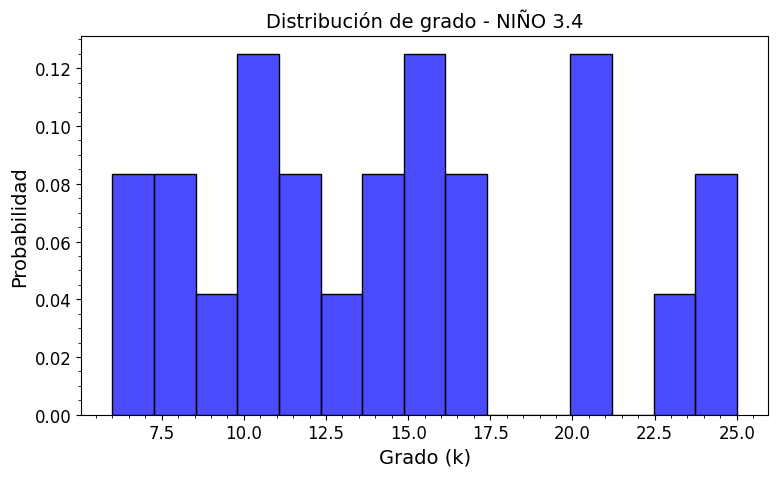

Distribución de grado - NIÑO 3.4
  Estadísticas: media=14.5000, varianza=31.0435, asimetría=0.3513, curtosis=-0.9280
  Segundo momento ⟨k²⟩ = 240.0000
  Exponente γ = 2.9971 ± 0.4582 (xmin = 10.0)
  p-valor (vs. exponencial) = 0.0018
  Grado mínimo: 6, máximo: 25



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


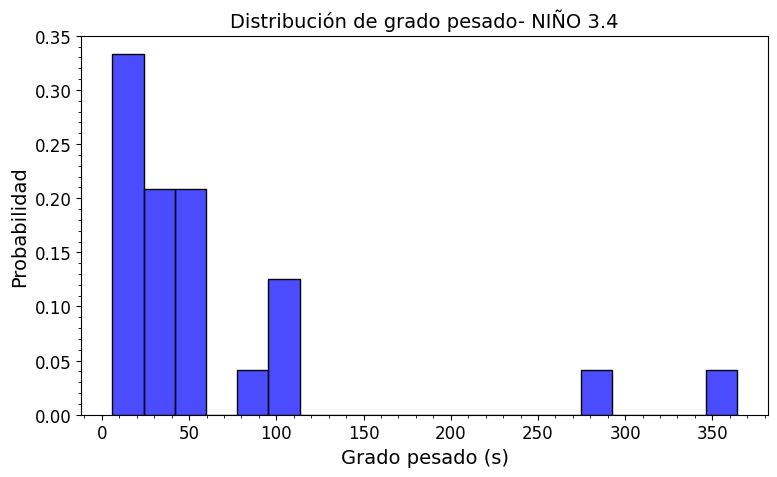

Distribución de grado pesado - NIÑO 3.4
  Estadísticas: media=66.4167, varianza=7575.2101, asimetría=2.4658, curtosis=5.3124
  Segundo momento ⟨s²⟩ = 11670.7500
  Exponente γ = 2.3442 ± 0.3361 (xmin = 32.0)
  p-valor (vs. exponencial) = 0.1584
  Fuerza mínima: 6.00, máxima: 364.00



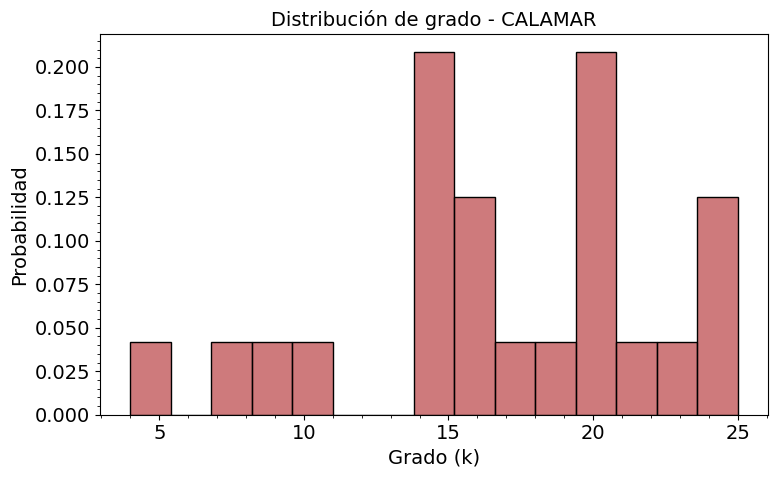

Distribución de grado - CALAMAR
  Estadísticas: media=16.9167, varianza=28.4275, asimetría=-0.6032, curtosis=-0.0849
  Segundo momento ⟨k²⟩ = 313.4167
  Exponente γ = 2.2448 ± 0.2596 (xmin = 8.0)
  p-valor (vs. exponencial) = 0.0000
  Grado mínimo: 4, máximo: 25



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


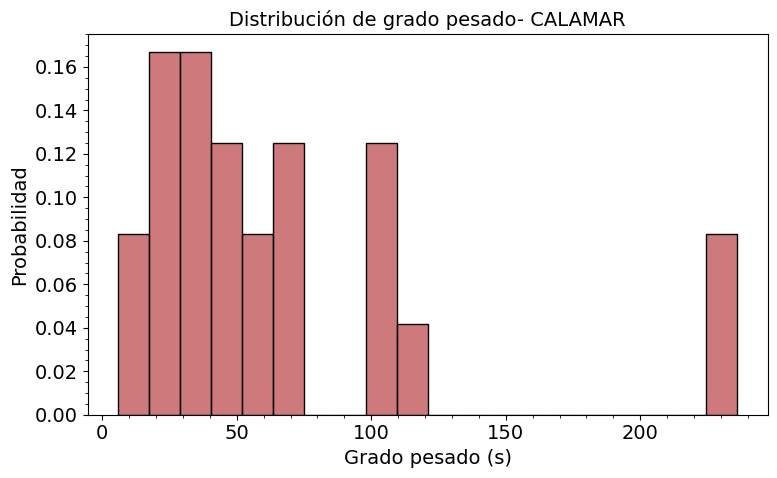

Distribución de grado pesado - CALAMAR
  Estadísticas: media=66.4167, varianza=3480.4275, asimetría=1.8081, curtosis=2.7188
  Segundo momento ⟨s²⟩ = 7746.5833
  Exponente γ = 2.3706 ± 0.3426 (xmin = 36.0)
  p-valor (vs. exponencial) = 0.7215
  Fuerza mínima: 6.00, máxima: 236.00



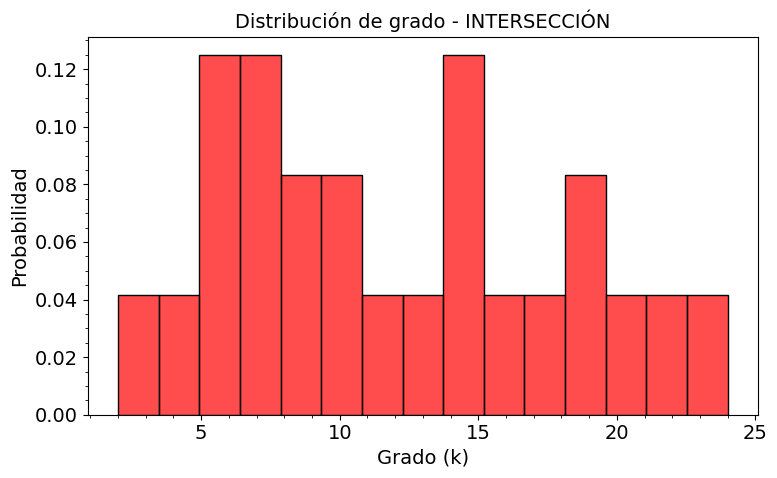

Distribución de grado - INTERSECCIÓN
  Estadísticas: media=11.8333, varianza=37.8841, asimetría=0.3234, curtosis=-0.9751
  Segundo momento ⟨k²⟩ = 176.3333
  Exponente γ = 2.0887 ± 0.2321 (xmin = 5.0)
  p-valor (vs. exponencial) = 0.0006
  Grado mínimo: 2, máximo: 24



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


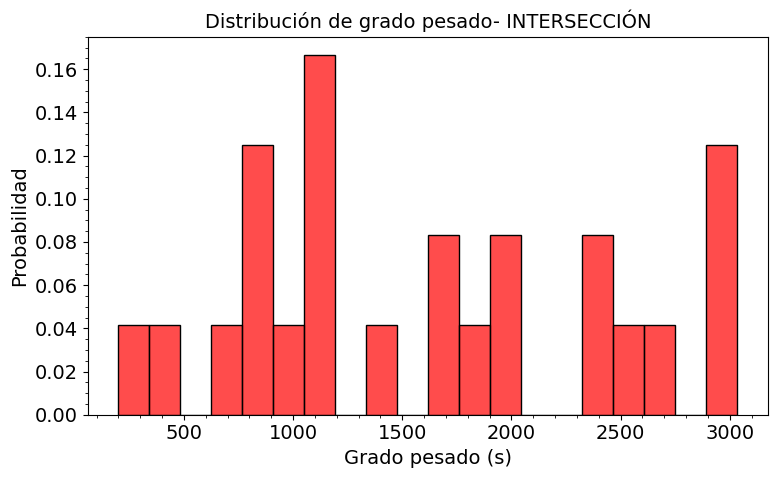

Distribución de grado pesado - INTERSECCIÓN
  Estadísticas: media=1616.4742, varianza=720831.3603, asimetría=0.2560, curtosis=-1.1427
  Segundo momento ⟨s²⟩ = 3303785.5937
  Exponente γ = 2.5449 ± 0.3371 (xmin = 850.0)
  p-valor (vs. exponencial) = 0.1182
  Fuerza mínima: 200.00, máxima: 3033.33



In [34]:
# Suponiendo que tienes G, G1 y GC definidos
plot_degree_distribution(G, "NIÑO 3.4", color='blue', bins=15, loglog=False)
plot_degree_distribution_pesada(G, "NIÑO 3.4", color='blue', bins=20, loglog=False)

plot_degree_distribution(G1, "CALAMAR", color='#ba4244', bins=15, loglog=False)
plot_degree_distribution_pesada(G1, "CALAMAR", color='#ba4244', bins=20, loglog=False)

plot_degree_distribution(GC, "INTERSECCIÓN", color='red', bins=15, loglog=False)
plot_degree_distribution_pesada(GC, "INTERSECCIÓN", color='red', bins=20, loglog=False)

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def correlacion_pearson(x, y, nombre_x='Serie X', nombre_y='Serie Y'):
    """
    Calcula la correlación de Pearson entre dos series y genera una gráfica de dispersión.

    Parámetros:
    x, y : listas o arrays unidimensionales de la misma longitud.
    nombre_x, nombre_y : etiquetas para los ejes.

    Retorna:
    r : coeficiente de correlación de Pearson.
    p : valor p asociado.
    """
    x = np.array(x)
    y = np.array(y)
    if len(x) != len(y):
        raise ValueError("Las series deben tener la misma longitud")

    # Calcular correlación de Pearson
    r, p = stats.pearsonr(x, y)

    # Ajuste lineal para la recta de regresión
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Crear gráfica
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=0.6, edgecolors='k', linewidth=0.5)
    # Recta de regresión
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, 'r-', label=f'Regresión lineal (r={r:.3f})')
    plt.xlabel(nombre_x)
    plt.ylabel(nombre_y)
    #plt.title(f'Correlación de Pearson: r={r:.3f}, p={p:.3e}')
    #plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

    print(f"Coeficiente de correlación de Pearson: r = {r:.4f}")
    print(f"Valor p: {p:.4e}")
    return r, p

##PEARSON

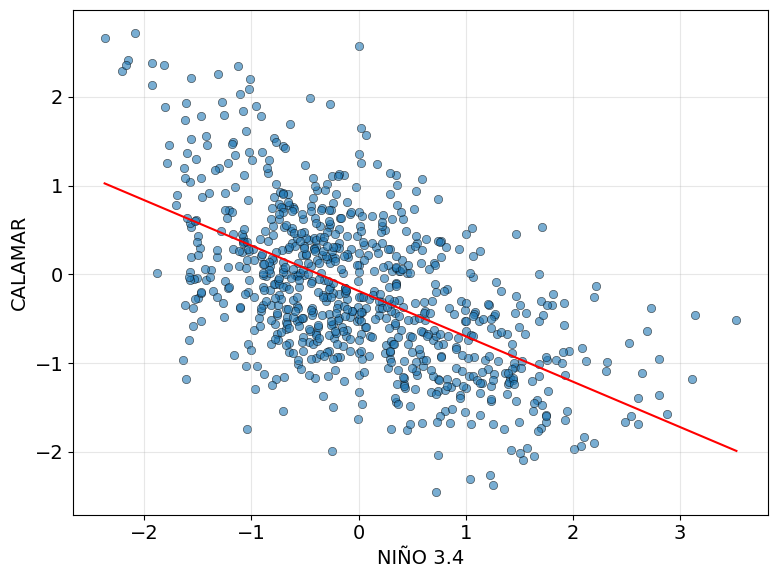

Coeficiente de correlación de Pearson: r = -0.5743
Valor p: 9.9392e-72


In [36]:
# Suponiendo que tienes las series x (NIÑO) y x1 (CALAMAR) definidas
r, p = correlacion_pearson(x1, x, nombre_y='CALAMAR', nombre_x='NIÑO 3.4')

##BOOTSTRAP

In [37]:
porcentaje_para_comparar=promedio
print(porcentaje_para_comparar)

33.67654605363318


Resultados del bootstrap clásico sobre x1 (1000 remuestras):
Media: 44.83
Mediana: 44.84
Desviación estándar: 2.00
Intervalo de confianza 95%: (41.06, 48.72)
Distancia del observado respecto a la media bootstrap: -5.58 desviaciones estándar


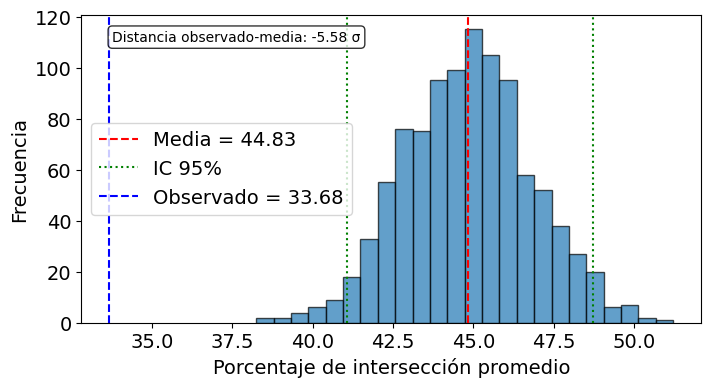

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
w_opt = 4
n_bootstrap = 1000          # número de remuestras
np.random.seed(42)          # para reproducibilidad

# Asegurarse de que A (matriz del niño) está calculada a partir de x
# Si no lo está, calcúlala aquí:
# nodos_x = crear_ind(x, w_opt)
# G_x, _, _ = crear_grafo(nodos_x, w_opt)
# A = nx.to_numpy_array(G_x, dtype=int)

# Lista para almacenar los resultados
porcents_boot = []

for i in range(n_bootstrap):
    # 1. Remuestrear x1 con reemplazo (bootstrap clásico)
    indices_boot = np.random.choice(len(x1), size=len(x1), replace=True)
    x1_boot = [x1[i] for i in indices_boot]   # si x1 es lista
    # Si x1 es array de numpy: x1_boot = x1[indices_boot]

    # 2. Obtener índices de patrones ordinales de la remuestra
    nodos_boot = crear_ind(x1_boot, w_opt)

    # 3. Construir grafo y matriz de adyacencia
    G_boot, _, _ = crear_grafo(nodos_boot, w_opt)
    A_boot = nx.to_numpy_array(G_boot, dtype=int)

    # 4. Calcular la métrica de similitud con A (la red del niño)
    with np.errstate(divide='ignore', invalid='ignore'):
        C = np.divide(A_boot, A, out=np.zeros_like(A, dtype=float), where=A != 0) * 100
    C_clean = np.where(np.isinf(C), 0, C)
    upper = np.triu(C_clean, k=1)          # triángulo superior sin diagonal
    promedio = np.mean(upper)               # promedio de todas las celdas (incluye ceros)
    # Si prefieres solo celdas con valor positivo:
    # promedio = np.mean(upper[upper > 0]) if np.any(upper > 0) else 0

    porcents_boot.append(promedio)

porcents_boot = np.array(porcents_boot)

# Estadísticos
media_boot = np.mean(porcents_boot)
mediana_boot = np.median(porcents_boot)
desv_boot = np.std(porcents_boot, ddof=1)
ic_inf = np.percentile(porcents_boot, 2.5)
ic_sup = np.percentile(porcents_boot, 97.5)
# Distancia del valor observado respecto a la media bootstrap (en desviaciones estándar)
distancia_sd = (porcentaje_para_comparar - media_boot) / desv_boot


print(f"Resultados del bootstrap clásico sobre x1 ({n_bootstrap} remuestras):")
print(f"Media: {media_boot:.2f}")
print(f"Mediana: {mediana_boot:.2f}")
print(f"Desviación estándar: {desv_boot:.2f}")
print(f"Intervalo de confianza 95%: ({ic_inf:.2f}, {ic_sup:.2f})")
print(f"Distancia del observado respecto a la media bootstrap: {distancia_sd:.2f} desviaciones estándar")

# Histograma
plt.figure(figsize=(8,4))
plt.hist(porcents_boot, bins='auto', alpha=0.7, edgecolor='black')
plt.axvline(media_boot, color='red', linestyle='--', label=f'Media = {media_boot:.2f}')
plt.axvline(ic_inf, color='green', linestyle=':', label='IC 95%')
plt.axvline(ic_sup, color='green', linestyle=':')
plt.axvline(porcentaje_para_comparar, color='blue', linestyle='--', label=f'Observado = {porcentaje_para_comparar:.2f}')
#plt.title('Distribución bootstrap de la similitud (A vs remuestras de x1)')
# Agregar anotación con la distancia en SD (opción con recuadro)
plt.text(0.05, 0.95, f'Distancia observado-media: {distancia_sd:.2f} σ',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.xlabel('Porcentaje de intersección promedio')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()